<a href="https://colab.research.google.com/github/Nwadiarugideon/Pediatric-bp-bmi-nhanes-comparison/blob/main/NHANES_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import the neccessary libraries needed
!pip install pandas
import pandas as pd
!pip install pandas pyreadstat
import pyreadstat
!pip install numpy
import numpy as np
from scipy.stats import chi2_contingency
!pip install matplotlib
import matplotlib.pyplot as plt
!pip install seaborn
import seaborn as sns
from scipy.stats import spearmanr

In [ ]:
#load the necessary files
uturu= pd.read_csv("uturu_rawdata.csv")
demo= pyreadstat.read_xport("DEMO_J.xpt")[0]
bp= pyreadstat.read_xport("BPX_J.xpt")[0]
bmi = pyreadstat.read_xport("BMX_J.xpt")[0]
who_zboys = pd.read_excel("bmi-boys-z-who-2007-exp.xlsx")
who_zgirls = pd.read_excel("bmi-girls-z-who-2007-exp.xlsx")
who_boysper = pd.read_excel("bmi-boys-perc-who2007-exp.xlsx")
who_girlsper = pd.read_excel("bmi-girls-perc-who2007-exp.xlsx")

In [ ]:
# Merge demographics and blood pressure dataset on SEQN
merge_file = pd.merge(demo, bp ,on = "SEQN")

In [ ]:
# Merge BMI dataset with the combined demographics and blood pressure data
df = merge_file.merge(bmi , on= "SEQN")

In [ ]:
#  Display the final merged dataset containing BMX,DEMO, and BPX variables
df

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,...,NaN,NaN,18.0,NaN,16.2,NaN,48.2,NaN,NaN,NaN
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,...,NaN,NaN,18.6,NaN,15.2,NaN,50.0,NaN,NaN,NaN
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,...,37.0,NaN,36.0,NaN,32.0,NaN,101.8,NaN,110.0,NaN
3,93706.0,10.0,2.0,1.0,18.0,NaN,5.0,6.0,2.0,222.0,...,46.6,NaN,38.8,NaN,27.0,NaN,79.3,NaN,94.4,NaN
4,93707.0,10.0,2.0,1.0,13.0,NaN,5.0,7.0,2.0,158.0,...,38.1,NaN,33.8,NaN,21.5,NaN,64.1,NaN,83.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8699,102952.0,10.0,2.0,2.0,70.0,NaN,5.0,6.0,2.0,NaN,...,34.4,NaN,32.6,NaN,25.1,NaN,82.2,NaN,87.3,NaN
8700,102953.0,10.0,2.0,1.0,42.0,NaN,1.0,1.0,2.0,NaN,...,38.2,NaN,36.6,NaN,40.6,NaN,114.8,NaN,112.8,NaN
8701,102954.0,10.0,2.0,2.0,41.0,NaN,4.0,4.0,1.0,NaN,...,39.2,NaN,35.2,NaN,26.8,NaN,86.4,NaN,102.7,NaN
8702,102955.0,10.0,2.0,2.0,14.0,NaN,4.0,4.0,2.0,175.0,...,39.2,NaN,35.0,NaN,44.5,NaN,113.5,NaN,128.3,NaN


In [ ]:
#Display the raw dataset uturu
uturu

,AGE_YEARS,SEX,WEIGHT_Kg,HEIGHT_m,SBP,DBP
0,6,M,18,0.98,114,56
1,6,F,15,1.02,93,55
2,6,M,15,1.06,117,55
3,6,M,12,1.04,118,59
4,6,F,16,1.03,94,56
...,...,...,...,...,...,...
135,19,M,71,1.62,128,81
136,19,F,55,1.48,122,80
137,19,M,68,1.63,126,80
138,19,F,58,1.41,125,82


In [ ]:
# Display first 5 rows of the merged dataset(NHANES)
df.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,...,NaN,NaN,18.0,NaN,16.2,NaN,48.2,NaN,NaN,NaN
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,...,NaN,NaN,18.6,NaN,15.2,NaN,50.0,NaN,NaN,NaN
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,...,37.0,NaN,36.0,NaN,32.0,NaN,101.8,NaN,110.0,NaN
3,93706.0,10.0,2.0,1.0,18.0,NaN,5.0,6.0,2.0,222.0,...,46.6,NaN,38.8,NaN,27.0,NaN,79.3,NaN,94.4,NaN
4,93707.0,10.0,2.0,1.0,13.0,NaN,5.0,7.0,2.0,158.0,...,38.1,NaN,33.8,NaN,21.5,NaN,64.1,NaN,83.0,NaN


In [ ]:
# Display first 5 rows of the raw uturu  dataset
uturu.head()

,AGE_YEARS,SEX,WEIGHT_Kg,HEIGHT_m,SBP,DBP
0,6,M,18,0.98,114,56
1,6,F,15,1.02,93,55
2,6,M,15,1.06,117,55
3,6,M,12,1.04,118,59
4,6,F,16,1.03,94,56


In [ ]:
# Display last 5 rows of the merged dataset(NHANES)
df.tail()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP
8699,102952.0,10.0,2.0,2.0,70.0,NaN,5.0,6.0,2.0,NaN,...,34.4,NaN,32.6,NaN,25.1,NaN,82.2,NaN,87.3,NaN
8700,102953.0,10.0,2.0,1.0,42.0,NaN,1.0,1.0,2.0,NaN,...,38.2,NaN,36.6,NaN,40.6,NaN,114.8,NaN,112.8,NaN
8701,102954.0,10.0,2.0,2.0,41.0,NaN,4.0,4.0,1.0,NaN,...,39.2,NaN,35.2,NaN,26.8,NaN,86.4,NaN,102.7,NaN
8702,102955.0,10.0,2.0,2.0,14.0,NaN,4.0,4.0,2.0,175.0,...,39.2,NaN,35.0,NaN,44.5,NaN,113.5,NaN,128.3,NaN
8703,102956.0,10.0,2.0,1.0,38.0,NaN,3.0,3.0,2.0,NaN,...,42.5,NaN,38.0,NaN,40.0,NaN,122.0,NaN,110.0,NaN


In [ ]:
#Display last 5 rows of the raw uturu dataset
uturu.tail()

,AGE_YEARS,SEX,WEIGHT_Kg,HEIGHT_m,SBP,DBP
135,19,M,71,1.62,128,81
136,19,F,55,1.48,122,80
137,19,M,68,1.63,126,80
138,19,F,58,1.41,125,82
139,19,M,76,1.58,130,81


In [ ]:
# Display column names of the merged dataset(NHANES)
df.columns

Index(['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN',
       'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMQADFC',
       'DMDBORN4', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDMARTL',
       'RIDEXPRG', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY',
       'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'DMDHHSIZ',
       'DMDFMSIZ', 'DMDHHSZA', 'DMDHHSZB', 'DMDHHSZE', 'DMDHRGND', 'DMDHRAGZ',
       'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVPSU',
       'SDMVSTRA', 'INDHHIN2', 'INDFMIN2', 'INDFMPIR', 'PEASCCT1', 'BPXCHR',
       'BPAARM', 'BPACSZ', 'BPXPLS', 'BPXPULS', 'BPXPTY', 'BPXML1', 'BPXSY1',
       'BPXDI1', 'BPAEN1', 'BPXSY2', 'BPXDI2', 'BPAEN2', 'BPXSY3', 'BPXDI3',
       'BPAEN3', 'BPXSY4', 'BPXDI4', 'BPAEN4', 'BMDSTATS', 'BMXWT', 'BMIWT',
       'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT',
       'BMXBMI', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC',
      

In [ ]:
# Display  column names of the raw uturu dataset
uturu.columns

Index(['AGE_YEARS', 'SEX', 'WEIGHT_Kg', 'HEIGHT_m', 'SBP', 'DBP'], dtype='object')

In [ ]:
#  Convert "WEIGHT_KG and  HEIGHT_m" columns to numeric (uturu)
uturu["WEIGHT_Kg"] = pd.to_numeric(uturu["WEIGHT_Kg"],errors = "coerce")
uturu["HEIGHT_m"] = pd.to_numeric(uturu["HEIGHT_m"], errors = "coerce")


In [ ]:
#  Select required columns from DEMO , BP, and BMI  datasets (NHANES)
demo_selected = demo[["SEQN","RIDAGEYR","RIAGENDR"]]
bp_selected = bp[["SEQN","BPXSY1", "BPXDI1"]]
bmi_selected = bmi[["SEQN","BMXBMI"]]

In [ ]:
#  Merge selected columns on SEQN (NHANES)
merge_file_sel = pd.merge(demo_selected,bp_selected,on = "SEQN",how = "inner")



In [ ]:
# Merge BMI data into the existing dataset on SEQN (NHANES)

merge_file_sel = pd.merge (merge_file_sel,bmi_selected,on= "SEQN", how = "left")

In [ ]:
# Display the merged dataset (NHANES)

merge_file_sel

,SEQN,RIDAGEYR,RIAGENDR,BPXSY1,BPXDI1,BMXBMI
0,93703.0,2.0,2.0,NaN,NaN,17.5
1,93704.0,2.0,1.0,NaN,NaN,15.7
2,93705.0,66.0,2.0,NaN,NaN,31.7
3,93706.0,18.0,1.0,112.0,74.0,21.5
4,93707.0,13.0,1.0,128.0,38.0,18.1
...,...,...,...,...,...,...
8699,102952.0,70.0,2.0,136.0,74.0,20.0
8700,102953.0,42.0,1.0,124.0,76.0,35.8
8701,102954.0,41.0,2.0,116.0,66.0,26.1
8702,102955.0,14.0,2.0,114.0,62.0,45.6


In [ ]:
# Rename columns (NHANES DATASET) to match the uturu dataset schema
file_sel = merge_file_sel.rename(columns={"RIDAGEYR": "AGE_YEARS",
                                                   "RIAGENDR" : "SEX",
                                                   "BMXBMI" : "BMI",
                                                   "BPXSY1" : "SBP",
                                                   "BPXDI1": "DBP"
                                                   })

In [ ]:
# Display the renamed dataset (NHANES DATASET)

file_sel

,SEQN,AGE_YEARS,SEX,SBP,DBP,BMI
0,93703.0,2.0,2.0,NaN,NaN,17.5
1,93704.0,2.0,1.0,NaN,NaN,15.7
2,93705.0,66.0,2.0,NaN,NaN,31.7
3,93706.0,18.0,1.0,112.0,74.0,21.5
4,93707.0,13.0,1.0,128.0,38.0,18.1
...,...,...,...,...,...,...
8699,102952.0,70.0,2.0,136.0,74.0,20.0
8700,102953.0,42.0,1.0,124.0,76.0,35.8
8701,102954.0,41.0,2.0,116.0,66.0,26.1
8702,102955.0,14.0,2.0,114.0,62.0,45.6


In [ ]:
#  Convert selected columns (AGE_YEARS, SEX, BMI, SBP, and DBP) to numeric
for col in ["AGE_YEARS","SEX","BMI","SBP", "DBP"]:
  file_sel[col] = pd.to_numeric(file_sel[col], errors = "coerce")

In [ ]:
#  Filter rows for ages 6 to 19  NHANES DATASET(file_sel)

file_sel = file_sel[(file_sel["AGE_YEARS"]>= 6) & (file_sel["AGE_YEARS"]<=19)].copy()

In [ ]:
#  Map SEX column to "M"  and "F" labels in NHANES DATASET(file_sel)
file_sel["SEX"] = file_sel["SEX"].map({1.0 : "M", 2.0: "F"})

In [ ]:
# Display the dataset(NHANES DATASET)
file_sel

,SEQN,AGE_YEARS,SEX,SBP,DBP,BMI
3,93706.0,18.0,M,112.0,74.0,21.5
4,93707.0,13.0,M,128.0,38.0,18.1
9,93712.0,18.0,M,112.0,68.0,19.7
16,93719.0,13.0,F,102.0,62.0,26.0
22,93725.0,9.0,F,NaN,NaN,16.1
...,...,...,...,...,...,...
8666,102915.0,14.0,F,98.0,66.0,25.1
8677,102926.0,15.0,F,94.0,36.0,20.4
8689,102941.0,14.0,F,NaN,NaN,20.1
8693,102945.0,15.0,M,106.0,68.0,22.1


In [ ]:
#  Check for missing values
file_sel.isnull().sum()

,0
SEQN,0
AGE_YEARS,0
SEX,0
SBP,527
DBP,527
BMI,27


In [ ]:
# Drop rows with missing values in SBP, DBP , and BMI

cleaned_file_sel = file_sel.dropna(subset =["SBP","DBP","BMI"])

In [ ]:
# Verify data cleaning

cleaned_file_sel.isnull().sum()

,0
SEQN,0
AGE_YEARS,0
SEX,0
SBP,0
DBP,0
BMI,0


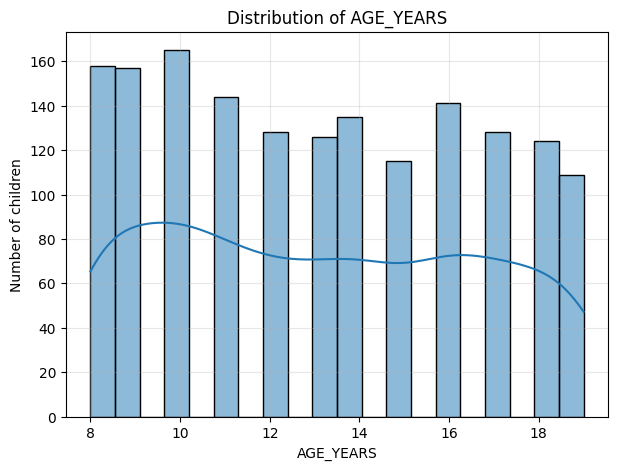

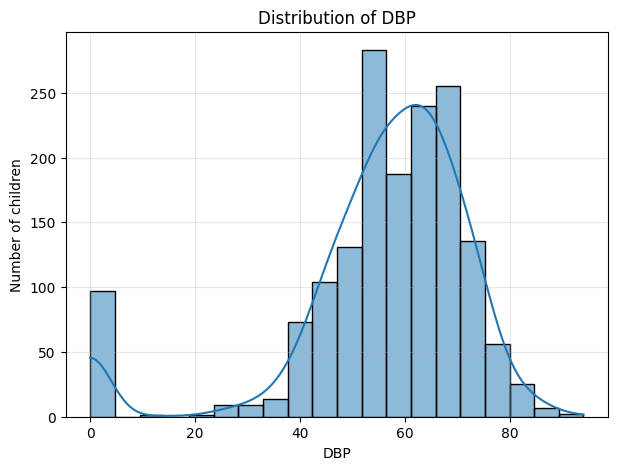

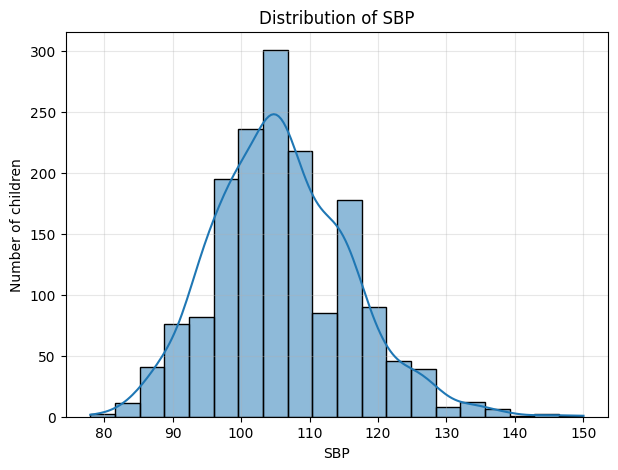

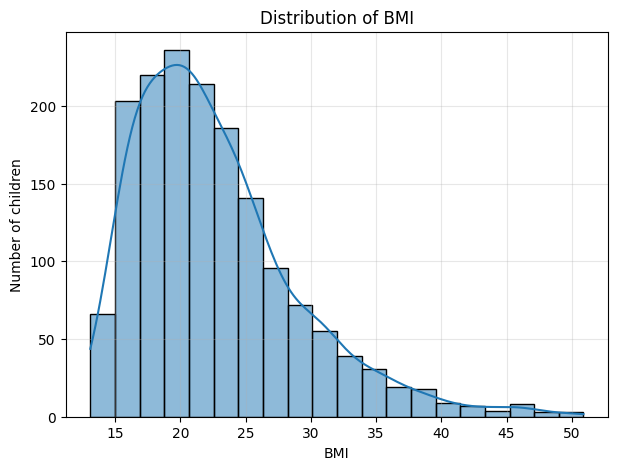

In [ ]:
 # Generate histogram with kernel density estimate for AGE_YEARS, DBP, SBP, and BMI  in the NHANES(cleaned_file_sel) dstaset



variables =["AGE_YEARS","DBP","SBP","BMI"]


for var in variables:

  plt.figure(figsize=(7,5))

  sns.histplot(
      data=cleaned_file_sel,
      x=var,
      bins=20,
      kde=True,

  )

  plt.title(f"Distribution of {var}")
  plt.xlabel(var)
  plt.ylabel("Number of children")


  plt.grid(alpha=0.3)
  plt.show()

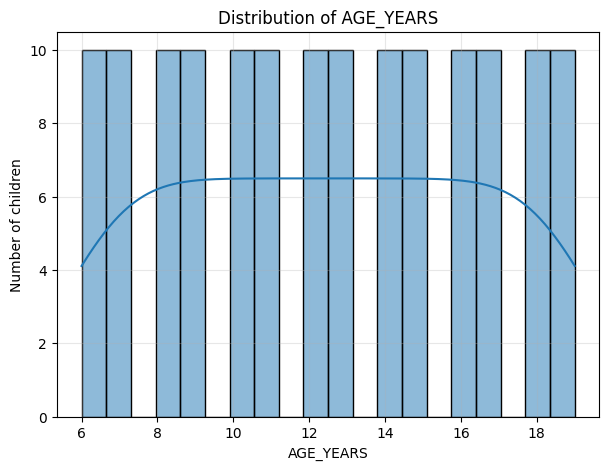

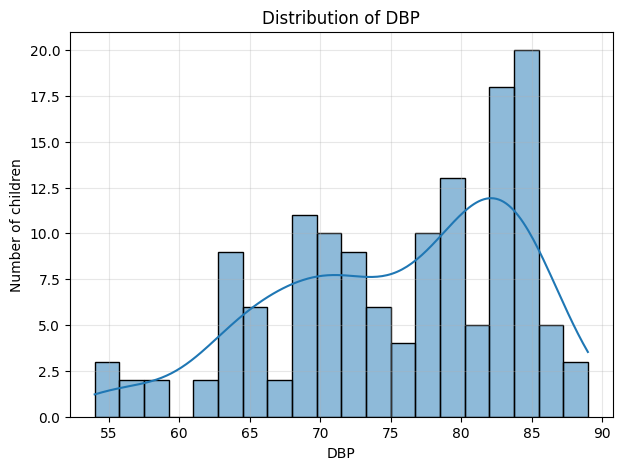

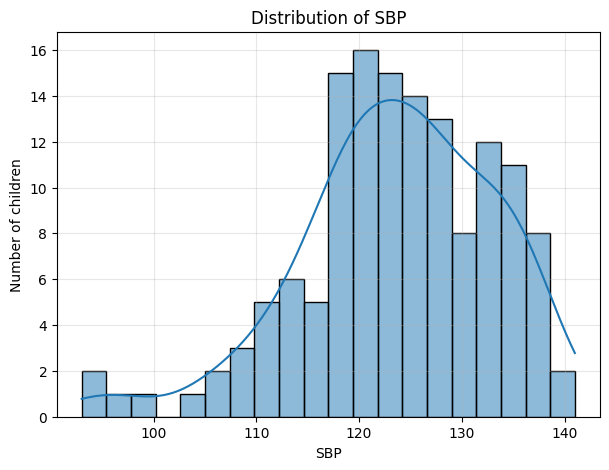

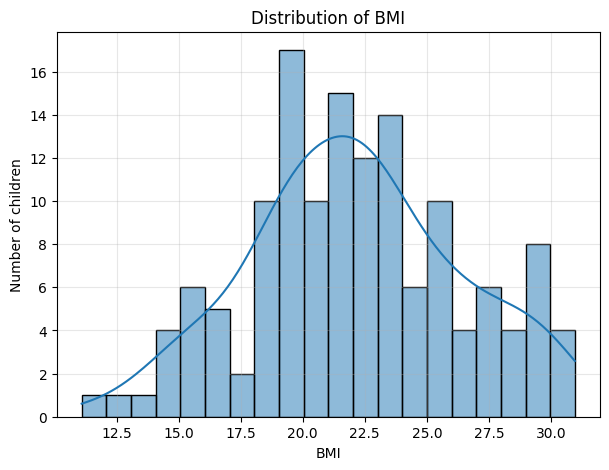

In [ ]:
 # Generate histogram with kernel density estimate for AGE_YEARS, DBP, SBP, and BMI  in the uturu dstaset

# Calculate BMI before plotting, as it's used in the variables list
uturu["BMI"] = uturu["WEIGHT_Kg"] / (uturu["HEIGHT_m"] **2)

variables =["AGE_YEARS","DBP","SBP","BMI"]


for var in variables:

  plt.figure(figsize=(7,5))
  sns.histplot(
      data=uturu,
      x=var,
      bins=20,
      kde=True,

  )

  plt.title(f"Distribution of {var}")
  plt.xlabel(var)
  plt.ylabel("Number of children")


  plt.grid(alpha=0.3)
  plt.show()

In [ ]:
# Generate summary statistics for numeric columns (NHANES DATASET)
cleaned_file_sel.describe()

,SEQN,AGE_YEARS,SBP,DBP,BMI
count,1630.000000,1630.000000,1630.000000,1630.000000,1630.000000
mean,98380.117791,13.150307,105.948466,55.755828,22.697239
std,2645.264021,3.464294,9.979835,17.589599,6.301418
min,93706.000000,8.000000,78.000000,0.000000,13.100000
25%,96051.250000,10.000000,100.000000,50.000000,18.100000
50%,98396.500000,13.000000,106.000000,58.000000,21.500000
75%,100660.750000,16.000000,112.000000,66.000000,25.800000
max,102955.000000,19.000000,150.000000,94.000000,50.900000


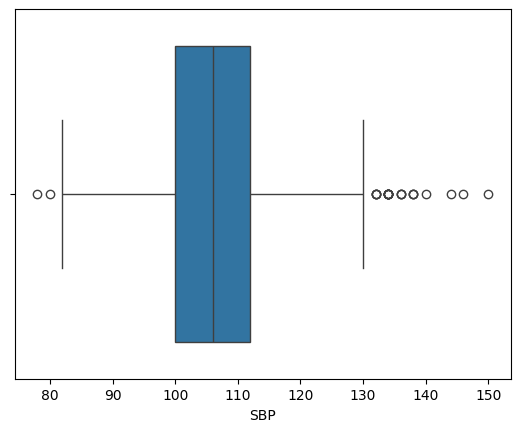

In [ ]:
# Check for outliers using boxplots
sns.boxplot(x= cleaned_file_sel["SBP"])
plt.show()

In [ ]:
# Remove outliers from column SBP
cleaned_file_sel = cleaned_file_sel[cleaned_file_sel["SBP"]>=80]

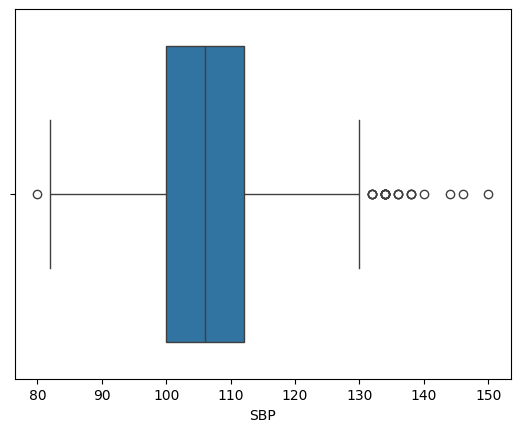

In [ ]:
# Visualize SBP distribution after outlier removal

sns.boxplot(x=cleaned_file_sel["SBP"])
plt.show()

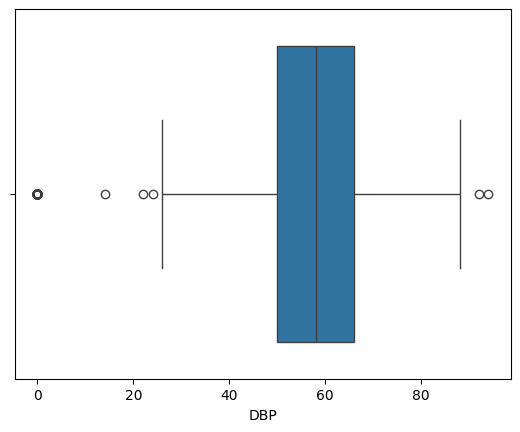

In [ ]:
#  Check for outlier in the DBP using a boxplot
sns.boxplot(x=cleaned_file_sel["DBP"])
plt.show()

In [ ]:
# Remove outliers found in the diastolic blood pressure column
cleaned_file_sel = cleaned_file_sel[cleaned_file_sel["DBP"]>=30]

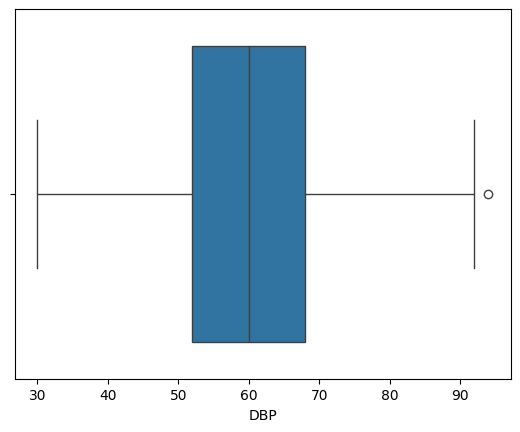

In [ ]:
#Visualize DBP distribution after outlier removal

sns.boxplot(x=cleaned_file_sel["DBP"])
plt.show()

In [ ]:
# Check dataset shape after outlier removal (NHANES DATASET)
cleaned_file_sel.shape

(1522, 6)

In [ ]:
# Display cleaned dataset (NHANES DATASET)

cleaned_file_sel

,SEQN,AGE_YEARS,SEX,SBP,DBP,BMI
3,93706.0,18.0,M,112.0,74.0,21.5
4,93707.0,13.0,M,128.0,38.0,18.1
9,93712.0,18.0,M,112.0,68.0,19.7
16,93719.0,13.0,F,102.0,62.0,26.0
30,93733.0,11.0,F,104.0,48.0,20.1
...,...,...,...,...,...,...
8663,102912.0,11.0,F,106.0,56.0,27.8
8666,102915.0,14.0,F,98.0,66.0,25.1
8677,102926.0,15.0,F,94.0,36.0,20.4
8693,102945.0,15.0,M,106.0,68.0,22.1


In [ ]:
# Check for duplicates(NHANES DATASET)
cleaned_file_sel.duplicated().sum()

np.int64(0)

In [ ]:
# Display uturu dataset

uturu

,AGE_YEARS,SEX,WEIGHT_Kg,HEIGHT_m,SBP,DBP,BMI
0,6,M,18,0.98,114,56,18.742191
1,6,F,15,1.02,93,55,14.417532
2,6,M,15,1.06,117,55,13.349947
3,6,M,12,1.04,118,59,11.094675
4,6,F,16,1.03,94,56,15.081535
...,...,...,...,...,...,...,...
135,19,M,71,1.62,128,81,27.053803
136,19,F,55,1.48,122,80,25.109569
137,19,M,68,1.63,126,80,25.593737
138,19,F,58,1.41,125,82,29.173583


In [ ]:
 # Calculate BMI for each record and add as a new column

 uturu["BMI"] = uturu["WEIGHT_Kg"] / (uturu["HEIGHT_m"] **2)

In [ ]:
# Display dataset with BMI column (uturu dataset)

uturu

,AGE_YEARS,SEX,WEIGHT_Kg,HEIGHT_m,SBP,DBP,BMI
0,6,M,18,0.98,114,56,18.742191
1,6,F,15,1.02,93,55,14.417532
2,6,M,15,1.06,117,55,13.349947
3,6,M,12,1.04,118,59,11.094675
4,6,F,16,1.03,94,56,15.081535
...,...,...,...,...,...,...,...
135,19,M,71,1.62,128,81,27.053803
136,19,F,55,1.48,122,80,25.109569
137,19,M,68,1.63,126,80,25.593737
138,19,F,58,1.41,125,82,29.173583


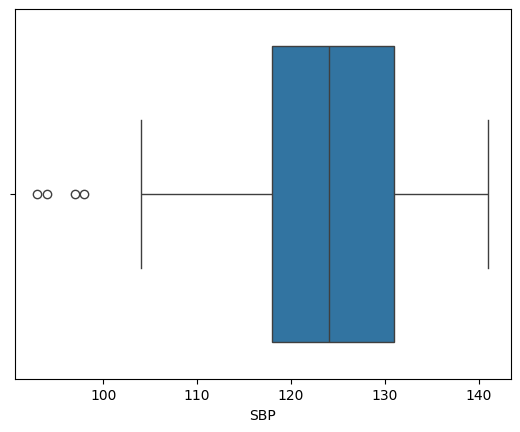

In [ ]:
# Check for outliers in SBP using a boxplot
sns.boxplot(x= uturu["SBP"])
plt.show()

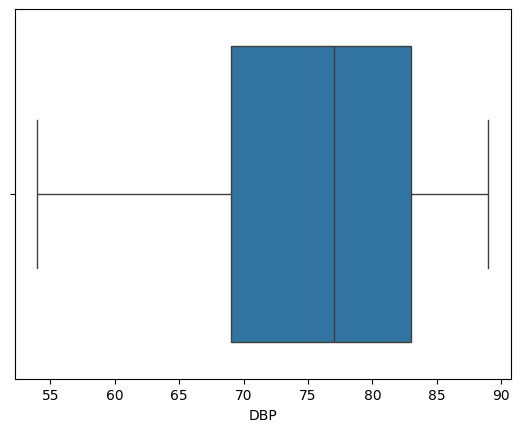

In [ ]:
# Check for outliers in DBP using a boxplot (NHANES DATASET)
sns.boxplot(x=uturu["DBP"])
plt.show()

In [ ]:
# Verify dataset(uturu) shape after outlier removal
uturu.shape

(140, 7)

In [ ]:
# Check for duplicate rows
uturu.duplicated().sum()

np.int64(0)

In [ ]:
#  Convert age from years to months

uturu["AGE_MONTHS"] = (uturu["AGE_YEARS"]*12).round().astype(int)

In [ ]:
# Convert age from years to months in cleaned_file_sel(NHANES DATASET)
cleaned_file_sel["AGE_MONTHS"] = (cleaned_file_sel["AGE_YEARS"]* 12).round().astype(int)

In [ ]:
# Convert height from meters to centimeters and round to 0.1 cm  for WHO standard alignment for uturu dataset
uturu["HEIGHT_cm"] = (uturu["HEIGHT_m"]*100).round(1)

In [ ]:
# Display dataset to verify previous transformation in uturu dataset

uturu

,AGE_YEARS,SEX,WEIGHT_Kg,HEIGHT_m,SBP,DBP,BMI,AGE_MONTHS,HEIGHT_cm
0,6,M,18,0.98,114,56,18.742191,72,98.0
1,6,F,15,1.02,93,55,14.417532,72,102.0
2,6,M,15,1.06,117,55,13.349947,72,106.0
3,6,M,12,1.04,118,59,11.094675,72,104.0
4,6,F,16,1.03,94,56,15.081535,72,103.0
...,...,...,...,...,...,...,...,...,...
135,19,M,71,1.62,128,81,27.053803,228,162.0
136,19,F,55,1.48,122,80,25.109569,228,148.0
137,19,M,68,1.63,126,80,25.593737,228,163.0
138,19,F,58,1.41,125,82,29.173583,228,141.0


In [ ]:
# Split dataset by sex

uturu_boys = uturu[uturu["SEX"]=="M"]
uturu_girls = uturu[uturu["SEX"]=="F"]

In [ ]:
# Split cleaned_file_sel(NHANES) dataset by sex
nhanes_boys = cleaned_file_sel[cleaned_file_sel["SEX"]=="M"]
nhanes_girls = cleaned_file_sel[cleaned_file_sel["SEX"]=="F"]

In [ ]:
# Rename "Month" column to "AGE_MONTHS" in WHO Z-score tables
who_zboys = who_zboys.rename(columns={"Month": "AGE_MONTHS"})
who_zgirls = who_zgirls.rename(columns={"Month": "AGE_MONTHS"})

In [ ]:
# Display columns in WHO Z-score table

who_zboys.columns

Index(['AGE_MONTHS', 'L', 'M', 'S', 'SD4neg', 'SD3neg', 'SD2neg', 'SD1neg',
       'SD0', 'SD1', 'SD2', 'SD3', 'SD4'],
      dtype='object')

In [ ]:
# Merge Uturu boys dataset with WHO Z-score table on AGE_MONTHS

uturu_boys = uturu[uturu["SEX"]=="M"].merge(
    who_zboys,
    on= "AGE_MONTHS",
     how="left"
)

In [ ]:
# Merge nhanes boys(cleaned_file_sel) dataset with WHO Z-score table on AGE_MONTHS


nhanes_boys = cleaned_file_sel[cleaned_file_sel["SEX"]=="M"].merge(
    who_zboys,
    on= "AGE_MONTHS",
    how="left"
)

In [ ]:
# Merge Uturu girls dataset with WHO Z-score table on AGE_MONTHS


uturu_girls = uturu[uturu["SEX"]=="F"].merge(
    who_zgirls,
    on= "AGE_MONTHS",
    how="left"
)

In [ ]:
# Merge nhanes girls(cleaned_file_sel) dataset with WHO Z-score table on AGE_MONTHS


nhanes_girls = cleaned_file_sel[cleaned_file_sel["SEX"]=="F"].merge(
    who_zgirls,
    on="AGE_MONTHS",
    how="left"
)

In [ ]:
uturu_boys.head() # Display first 5 rows of the uturu boys dataset

,AGE_YEARS,SEX,WEIGHT_Kg,HEIGHT_m,SBP,DBP,BMI,AGE_MONTHS,HEIGHT_cm,L,...,S,SD4neg,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3,SD4
0,6,M,18,0.98,114,56,18.742191,72,98.0,-0.9921,...,0.08682,11.242,12.141,13.04,14.083,15.306,16.761,18.52,20.689,22.858
1,6,M,15,1.06,117,55,13.349947,72,106.0,-0.9921,...,0.08682,11.242,12.141,13.04,14.083,15.306,16.761,18.52,20.689,22.858
2,6,M,12,1.04,118,59,11.094675,72,104.0,-0.9921,...,0.08682,11.242,12.141,13.04,14.083,15.306,16.761,18.52,20.689,22.858
3,6,M,20,1.04,118,54,18.491124,72,104.0,-0.9921,...,0.08682,11.242,12.141,13.04,14.083,15.306,16.761,18.52,20.689,22.858
4,6,M,21,1.05,120,64,19.047619,72,105.0,-0.9921,...,0.08682,11.242,12.141,13.04,14.083,15.306,16.761,18.52,20.689,22.858


In [ ]:
uturu_girls.head()  # Display first 5 rows of the uturu girls dataset

,AGE_YEARS,SEX,WEIGHT_Kg,HEIGHT_m,SBP,DBP,BMI,AGE_MONTHS,HEIGHT_cm,L,...,S,SD4neg,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3,SD4
0,6,F,15,1.02,93,55,14.417532,72,102.0,-1.0794,...,0.10195,10.747,11.723,12.7,13.862,15.27,17.011,19.224,22.133,25.042
1,6,F,16,1.03,94,56,15.081535,72,103.0,-1.0794,...,0.10195,10.747,11.723,12.7,13.862,15.27,17.011,19.224,22.133,25.042
2,6,F,21,1.12,97,58,16.741071,72,112.0,-1.0794,...,0.10195,10.747,11.723,12.7,13.862,15.27,17.011,19.224,22.133,25.042
3,6,F,19,1.15,98,61,14.366730,72,115.0,-1.0794,...,0.10195,10.747,11.723,12.7,13.862,15.27,17.011,19.224,22.133,25.042
4,6,F,25,1.17,104,63,18.262839,72,117.0,-1.0794,...,0.10195,10.747,11.723,12.7,13.862,15.27,17.011,19.224,22.133,25.042


In [ ]:
nhanes_boys.head()  # Display first 5 rows of the nhanes boys dataset

,SEQN,AGE_YEARS,SEX,SBP,DBP,BMI,AGE_MONTHS,L,M,S,SD4neg,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3,SD4
0,93706.0,18.0,M,112.0,74.0,21.5,216,-1.0260,21.7077,0.12836,14.100,15.692,17.284,19.242,21.708,24.911,29.243,35.432,41.621
1,93707.0,13.0,M,128.0,38.0,18.1,156,-1.7168,18.2330,0.11898,12.669,13.802,14.935,16.362,18.233,20.829,24.757,31.686,38.616
2,93712.0,18.0,M,112.0,68.0,19.7,216,-1.0260,21.7077,0.12836,14.100,15.692,17.284,19.242,21.708,24.911,29.243,35.432,41.621
3,93736.0,11.0,M,108.0,70.0,17.9,132,-1.7862,16.9392,0.11070,12.046,13.051,14.056,15.312,16.939,19.163,22.452,28.027,33.602
4,93803.0,12.0,M,106.0,54.0,20.0,144,-1.7751,17.5334,0.11522,12.328,13.391,14.453,15.788,17.533,19.946,23.581,29.957,36.333


In [ ]:
nhanes_girls.head()  # Display first 5 rows of the nhanes girls dataset

,SEQN,AGE_YEARS,SEX,SBP,DBP,BMI,AGE_MONTHS,L,M,S,SD4neg,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3,SD4
0,93719.0,13.0,F,102.0,62.0,26.0,156,-1.3195,18.8012,0.13445,12.276,13.606,14.936,16.612,18.801,21.800,26.207,33.439,40.670
1,93733.0,11.0,F,104.0,48.0,20.1,132,-1.4606,17.2459,0.12748,11.569,12.727,13.885,15.343,17.246,19.859,23.725,30.189,36.653
2,93747.0,13.0,F,106.0,70.0,22.1,156,-1.3195,18.8012,0.13445,12.276,13.606,14.936,16.612,18.801,21.800,26.207,33.439,40.670
3,93753.0,10.0,F,120.0,64.0,24.6,120,-1.4864,16.6133,0.12307,11.285,12.378,13.470,14.838,16.613,19.032,22.570,28.378,34.185
4,93778.0,19.0,F,102.0,70.0,27.4,228,-0.7496,21.4269,0.14441,12.951,14.724,16.497,18.681,21.427,24.965,29.670,36.179,42.689


In [ ]:
# Calculate BMI Z-score for uturu boys and girls using WHO  LMS parameters

uturu_boys["BMI_Z"] = ((uturu_boys["BMI"]/uturu_boys["M"])**uturu_boys["L"] - 1)/(uturu_boys["L"]*uturu_boys["S"])
uturu_girls["BMI_Z"] = ((uturu_girls["BMI"]/uturu_girls["M"])**uturu_girls["L"]- 1)/(uturu_girls["L"]*uturu_girls["S"])

In [ ]:
# Calculate BMI Z-score for nhanes boys and girls using WHO  LMS parameters


nhanes_boys["BMI_Z"] = ((nhanes_boys["BMI"]/nhanes_boys["M"])**nhanes_boys["L"] - 1)/(nhanes_boys["L"]* nhanes_boys["S"])
nhanes_girls["BMI_Z"] = ((nhanes_girls["BMI"]/nhanes_girls["M"])** nhanes_girls["L"]- 1)/(nhanes_girls["L"]* nhanes_girls["S"])

In [ ]:
# Display uturu boys dataset

uturu_boys

,AGE_YEARS,SEX,WEIGHT_Kg,HEIGHT_m,SBP,DBP,BMI,AGE_MONTHS,HEIGHT_cm,L,...,SD4neg,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3,SD4,BMI_Z
0,6,M,18,0.98,114,56,18.742191,72,98.0,-0.9921,...,11.242,12.141,13.040,14.083,15.306,16.761,18.520,20.689,22.858,2.113234
1,6,M,15,1.06,117,55,13.349947,72,106.0,-0.9921,...,11.242,12.141,13.040,14.083,15.306,16.761,18.520,20.689,22.858,-1.686887
2,6,M,12,1.04,118,59,11.094675,72,104.0,-0.9921,...,11.242,12.141,13.040,14.083,15.306,16.761,18.520,20.689,22.858,-4.366401
3,6,M,20,1.04,118,54,18.491124,72,104.0,-0.9921,...,11.242,12.141,13.040,14.083,15.306,16.761,18.520,20.689,22.858,1.985318
4,6,M,21,1.05,120,64,19.047619,72,105.0,-0.9921,...,11.242,12.141,13.040,14.083,15.306,16.761,18.520,20.689,22.858,2.264318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,19,M,63,1.71,122,80,21.545091,228,171.0,-0.8419,...,14.156,15.855,17.554,19.622,22.188,25.449,29.716,35.516,41.317,-0.230031
66,19,M,67,1.65,126,78,24.609734,228,165.0,-0.8419,...,14.156,15.855,17.554,19.622,22.188,25.449,29.716,35.516,41.317,0.766059
67,19,M,71,1.62,128,81,27.053803,228,162.0,-0.8419,...,14.156,15.855,17.554,19.622,22.188,25.449,29.716,35.516,41.317,1.410250
68,19,M,68,1.63,126,80,25.593737,228,163.0,-0.8419,...,14.156,15.855,17.554,19.622,22.188,25.449,29.716,35.516,41.317,1.039037


In [ ]:
nhanes_boys  # Display nhanes boys dataset

,SEQN,AGE_YEARS,SEX,SBP,DBP,BMI,AGE_MONTHS,L,M,S,SD4neg,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3,SD4,BMI_Z
0,93706.0,18.0,M,112.0,74.0,21.5,216,-1.0260,21.7077,0.12836,14.100,15.692,17.284,19.242,21.708,24.911,29.243,35.432,41.621,-0.075270
1,93707.0,13.0,M,128.0,38.0,18.1,156,-1.7168,18.2330,0.11898,12.669,13.802,14.935,16.362,18.233,20.829,24.757,31.686,38.616,-0.061921
2,93712.0,18.0,M,112.0,68.0,19.7,216,-1.0260,21.7077,0.12836,14.100,15.692,17.284,19.242,21.708,24.911,29.243,35.432,41.621,-0.794987
3,93736.0,11.0,M,108.0,70.0,17.9,132,-1.7862,16.9392,0.11070,12.046,13.051,14.056,15.312,16.939,19.163,22.452,28.027,33.602,0.474607
4,93803.0,12.0,M,106.0,54.0,20.0,144,-1.7751,17.5334,0.11522,12.328,13.391,14.453,15.788,17.533,19.946,23.581,29.957,36.333,1.018734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
761,102882.0,8.0,M,110.0,46.0,18.1,96,-1.4629,15.7368,0.09526,11.486,12.394,13.302,14.394,15.737,17.437,19.675,22.785,25.895,1.328164
762,102891.0,9.0,M,94.0,68.0,19.5,108,-1.6318,16.0490,0.10038,11.634,12.562,13.491,14.624,16.049,17.908,20.468,24.288,28.107,1.662196
763,102898.0,10.0,M,102.0,64.0,15.5,120,-1.7407,16.4433,0.10566,11.815,12.775,13.735,14.923,16.443,18.480,21.400,26.073,30.746,-0.588895
764,102909.0,12.0,M,104.0,58.0,15.0,144,-1.7751,17.5334,0.11522,12.328,13.391,14.453,15.788,17.533,19.946,23.581,29.957,36.333,-1.560623


In [ ]:
uturu_girls  # Display uturu girls dataset

,AGE_YEARS,SEX,WEIGHT_Kg,HEIGHT_m,SBP,DBP,BMI,AGE_MONTHS,HEIGHT_cm,L,...,SD4neg,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3,SD4,BMI_Z
0,6,F,15,1.02,93,55,14.417532,72,102.0,-1.0794,...,10.747,11.723,12.700,13.862,15.270,17.011,19.224,22.133,25.042,-0.581095
1,6,F,16,1.03,94,56,15.081535,72,103.0,-1.0794,...,10.747,11.723,12.700,13.862,15.270,17.011,19.224,22.133,25.042,-0.122439
2,6,F,21,1.12,97,58,16.741071,72,112.0,-1.0794,...,10.747,11.723,12.700,13.862,15.270,17.011,19.224,22.133,25.042,0.858996
3,6,F,19,1.15,98,61,14.366730,72,115.0,-1.0794,...,10.747,11.723,12.700,13.862,15.270,17.011,19.224,22.133,25.042,-0.618003
4,6,F,25,1.17,104,63,18.262839,72,117.0,-1.0794,...,10.747,11.723,12.700,13.862,15.270,17.011,19.224,22.133,25.042,1.596544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,19,F,61,1.58,124,78,24.435187,228,158.0,-0.7496,...,12.951,14.724,16.497,18.681,21.427,24.965,29.670,36.179,42.689,0.866389
66,19,F,54,1.52,120,79,23.372576,228,152.0,-0.7496,...,12.951,14.724,16.497,18.681,21.427,24.965,29.670,36.179,42.689,0.582684
67,19,F,53,1.56,121,77,21.778435,228,156.0,-0.7496,...,12.951,14.724,16.497,18.681,21.427,24.965,29.670,36.179,42.689,0.112002
68,19,F,55,1.48,122,80,25.109569,228,148.0,-0.7496,...,12.951,14.724,16.497,18.681,21.427,24.965,29.670,36.179,42.689,1.035501


In [ ]:
nhanes_girls  # Display nhanes girls dataset

,SEQN,AGE_YEARS,SEX,SBP,DBP,BMI,AGE_MONTHS,L,M,S,SD4neg,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3,SD4,BMI_Z
0,93719.0,13.0,F,102.0,62.0,26.0,156,-1.3195,18.8012,0.13445,12.276,13.606,14.936,16.612,18.801,21.800,26.207,33.439,40.670,1.961738
1,93733.0,11.0,F,104.0,48.0,20.1,132,-1.4606,17.2459,0.12748,11.569,12.727,13.885,15.343,17.246,19.859,23.725,30.189,36.653,1.076452
2,93747.0,13.0,F,106.0,70.0,22.1,156,-1.3195,18.8012,0.13445,12.276,13.606,14.936,16.612,18.801,21.800,26.207,33.439,40.670,1.082774
3,93753.0,10.0,F,120.0,64.0,24.6,120,-1.4864,16.6133,0.12307,11.285,12.378,13.470,14.838,16.613,19.032,22.570,28.378,34.185,2.416450
4,93778.0,19.0,F,102.0,70.0,27.4,228,-0.7496,21.4269,0.14441,12.951,14.724,16.497,18.681,21.427,24.965,29.670,36.179,42.689,1.555046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,102905.0,13.0,F,108.0,58.0,28.0,156,-1.3195,18.8012,0.13445,12.276,13.606,14.936,16.612,18.801,21.800,26.207,33.439,40.670,2.304091
752,102912.0,11.0,F,106.0,56.0,27.8,132,-1.4606,17.2459,0.12748,11.569,12.727,13.885,15.343,17.246,19.859,23.725,30.189,36.653,2.696667
753,102915.0,14.0,F,98.0,66.0,25.1,168,-1.2266,19.5647,0.13700,12.604,14.026,15.448,17.238,19.565,22.731,27.321,34.660,41.999,1.566945
754,102926.0,15.0,F,94.0,36.0,20.4,180,-1.1311,20.2125,0.13904,12.853,14.362,15.871,17.764,20.212,23.514,28.224,35.538,42.852,0.066065


In [ ]:
# Concatenate Uturu boys and girls dataset into a single Dataframe

uturu_final = pd.concat([uturu_boys,uturu_girls])

In [ ]:
# Concatenate nhanes boys and girls dataset into a single Dataframe

nhanes_final = pd.concat([nhanes_boys, nhanes_girls])

In [ ]:
# Display first 10 rows of selected columns from the uturu final dataset

uturu_final[["AGE_MONTHS","BMI","L","M","S","BMI_Z"]].head(10)

,AGE_MONTHS,BMI,L,M,S,BMI_Z
0,72,18.742191,-0.9921,15.3062,0.08682,2.113234
1,72,13.349947,-0.9921,15.3062,0.08682,-1.686887
2,72,11.094675,-0.9921,15.3062,0.08682,-4.366401
3,72,18.491124,-0.9921,15.3062,0.08682,1.985318
4,72,19.047619,-0.9921,15.3062,0.08682,2.264318
5,84,17.301038,-1.2460,15.4832,0.09068,1.143312
6,84,19.794514,-1.2460,15.4832,0.09068,2.333639
7,84,14.792899,-1.2460,15.4832,0.09068,-0.517524
8,84,19.929847,-1.2460,15.4832,0.09068,2.388732
9,84,18.667316,-1.2460,15.4832,0.09068,1.839733


In [ ]:
# Display first 10 rows of selected columns from the nhanes final dataset

nhanes_final[["AGE_MONTHS","BMI","L","M","S","BMI_Z"]].head(10)

,AGE_MONTHS,BMI,L,M,S,BMI_Z
0,216,21.5,-1.0260,21.7077,0.12836,-0.075270
1,156,18.1,-1.7168,18.2330,0.11898,-0.061921
2,216,19.7,-1.0260,21.7077,0.12836,-0.794987
3,132,17.9,-1.7862,16.9392,0.11070,0.474607
4,144,20.0,-1.7751,17.5334,0.11522,1.018734
5,168,28.3,-1.6211,19.0050,0.12191,2.406422
6,120,24.9,-1.7407,16.4433,0.10566,2.796655
7,228,21.3,-0.8419,22.1883,0.12948,-0.321045
8,120,30.1,-1.7407,16.4433,0.10566,3.539074
9,120,28.7,-1.7407,16.4433,0.10566,3.375011


In [ ]:
# Categorize BMI Z-score into WHO  weight status categories

def categorize_bmi(z):
    if z < -3:
      return "severe thinness"
    elif z < -2:
      return "Thinness"
    elif z <= 1:
      return "Normal"
    elif z <= 2:
      return "Overweight"
    else:
      return "Obese"

In [ ]:
# Assign BMI category to each row in the uturu dataset

uturu_final["BMI_CATEGORY"] = uturu_final["BMI_Z"].apply(categorize_bmi)

In [ ]:
# Assign BMI category to each row in the nhanes dataset

nhanes_final["BMI_CATEGORY"] = nhanes_final["BMI_Z"].apply(categorize_bmi)

In [ ]:
# Calculate proportion of each BMI category by age and sex for uturu dataset

df = uturu_final.groupby(["AGE_MONTHS","SEX"])["BMI_CATEGORY"].value_counts(normalize=True).unstack(fill_value=0)


In [ ]:
# Calculate proportion of each BMI category by age and sex for nhanes dataset


dt= nhanes_final.groupby(["AGE_MONTHS","SEX"])["BMI_CATEGORY"].value_counts(normalize=True).unstack(fill_value=0)

In [ ]:
df # display the uturu dataset

BMI_CATEGORY    Normal  Obese  Overweight  Thinness  severe thinness
AGE_MONTHS SEX                                                      
72         F       0.8    0.0         0.2       0.0              0.0
           M       0.2    0.4         0.2       0.0              0.2
84         F       0.4    0.6         0.0       0.0              0.0
           M       0.2    0.4         0.4       0.0              0.0
96         F       0.6    0.4         0.0       0.0              0.0
           M       0.2    0.2         0.6       0.0              0.0
108        F       0.2    0.4         0.4       0.0              0.0
           M       0.0    0.4         0.6       0.0              0.0
120        F       0.4    0.4         0.2       0.0              0.0
           M       0.0    0.4         0.6       0.0              0.0
132        F       0.4    0.2         0.4       0.0              0.0
           M       0.0    0.4         0.6       0.0              0.0
144        F       0.4    0.0         0.6       0.0              0.0
           M       0.0    0.2         0.8       0.0              0.0
156        F       0.2    0.2         0.6       0.0              0.0
           M       0.0    0.6         0.4       0.0              0.0
168        F       0.8    0.0         0.2       0.0              0.0
           M       0.4    0.6         0.0       0.0              0.0
180        F       0.6    0.0         0.2       0.2              0.0
           M       0.0    0.6         0.4       0.0              0.0
192        F       0.6    0.4         0.0       0.0              0.0
           M       0.4    0.4         0.2       0.0              0.0
204        F       0.6    0.0         0.4       0.0              0.0
           M       0.2    0.0         0.8       0.0              0.0
216        F       0.6    0.2         0.2       0.0              0.0
           M       0.6    0.2         0.2       0.0              0.0
228        F       0.6    0.0         0.4       0.0              0.0
           M       0.4    0.2         0.4       0.0              0.0

In [ ]:
dt  # Display the nhanes dataset

BMI_CATEGORY      Normal     Obese  Overweight  Thinness  severe thinness
AGE_MONTHS SEX                                                           
96         F    0.537037  0.222222    0.240741  0.000000         0.000000
           M    0.529412  0.279412    0.176471  0.014706         0.000000
108        F    0.557377  0.262295    0.180328  0.000000         0.000000
           M    0.461538  0.246154    0.276923  0.015385         0.000000
120        F    0.436620  0.309859    0.239437  0.014085         0.000000
           M    0.448718  0.333333    0.217949  0.000000         0.000000
132        F    0.439024  0.280488    0.268293  0.012195         0.000000
           M    0.518519  0.296296    0.185185  0.000000         0.000000
144        F    0.322034  0.271186    0.389831  0.016949         0.000000
           M    0.523077  0.276923    0.184615  0.015385         0.000000
156        F    0.483871  0.290323    0.225806  0.000000         0.000000
           M    0.466667  0.250000    0.266667  0.016667         0.000000
168        F    0.422535  0.267606    0.309859  0.000000         0.000000
           M    0.516667  0.300000    0.166667  0.016667         0.000000
180        F    0.509804  0.313725    0.176471  0.000000         0.000000
           M    0.492063  0.269841    0.206349  0.031746         0.000000
192        F    0.571429  0.228571    0.185714  0.014286         0.000000
           M    0.558824  0.205882    0.220588  0.000000         0.014706
204        F    0.542373  0.220339    0.220339  0.016949         0.000000
           M    0.536232  0.289855    0.144928  0.028986         0.000000
216        F    0.532258  0.258065    0.177419  0.032258         0.000000
           M    0.532258  0.258065    0.177419  0.016129         0.016129
228        F    0.500000  0.240741    0.222222  0.037037         0.000000
           M    0.462963  0.222222    0.296296  0.018519         0.000000

In [ ]:
# Convert BMI category proportions to percentages and round to 1 decimal place for uturu dataset

df =( df *100).round(1)

In [ ]:
# Convert BMI category proportions to percentages and round to 1 decimal place for nhanes dataset

dt = (dt *100).round(1)

In [ ]:
df # Display uturu dataset

BMI_CATEGORY    Normal  Obese  Overweight  Thinness  severe thinness
AGE_MONTHS SEX                                                      
72         F      80.0    0.0        20.0       0.0              0.0
           M      20.0   40.0        20.0       0.0             20.0
84         F      40.0   60.0         0.0       0.0              0.0
           M      20.0   40.0        40.0       0.0              0.0
96         F      60.0   40.0         0.0       0.0              0.0
           M      20.0   20.0        60.0       0.0              0.0
108        F      20.0   40.0        40.0       0.0              0.0
           M       0.0   40.0        60.0       0.0              0.0
120        F      40.0   40.0        20.0       0.0              0.0
           M       0.0   40.0        60.0       0.0              0.0
132        F      40.0   20.0        40.0       0.0              0.0
           M       0.0   40.0        60.0       0.0              0.0
144        F      40.0    0.0        60.0       0.0              0.0
           M       0.0   20.0        80.0       0.0              0.0
156        F      20.0   20.0        60.0       0.0              0.0
           M       0.0   60.0        40.0       0.0              0.0
168        F      80.0    0.0        20.0       0.0              0.0
           M      40.0   60.0         0.0       0.0              0.0
180        F      60.0    0.0        20.0      20.0              0.0
           M       0.0   60.0        40.0       0.0              0.0
192        F      60.0   40.0         0.0       0.0              0.0
           M      40.0   40.0        20.0       0.0              0.0
204        F      60.0    0.0        40.0       0.0              0.0
           M      20.0    0.0        80.0       0.0              0.0
216        F      60.0   20.0        20.0       0.0              0.0
           M      60.0   20.0        20.0       0.0              0.0
228        F      60.0    0.0        40.0       0.0              0.0
           M      40.0   20.0        40.0       0.0              0.0

In [ ]:
dt # Display nhanes dataset

BMI_CATEGORY    Normal  Obese  Overweight  Thinness  severe thinness
AGE_MONTHS SEX                                                      
96         F      53.7   22.2        24.1       0.0              0.0
           M      52.9   27.9        17.6       1.5              0.0
108        F      55.7   26.2        18.0       0.0              0.0
           M      46.2   24.6        27.7       1.5              0.0
120        F      43.7   31.0        23.9       1.4              0.0
           M      44.9   33.3        21.8       0.0              0.0
132        F      43.9   28.0        26.8       1.2              0.0
           M      51.9   29.6        18.5       0.0              0.0
144        F      32.2   27.1        39.0       1.7              0.0
           M      52.3   27.7        18.5       1.5              0.0
156        F      48.4   29.0        22.6       0.0              0.0
           M      46.7   25.0        26.7       1.7              0.0
168        F      42.3   26.8        31.0       0.0              0.0
           M      51.7   30.0        16.7       1.7              0.0
180        F      51.0   31.4        17.6       0.0              0.0
           M      49.2   27.0        20.6       3.2              0.0
192        F      57.1   22.9        18.6       1.4              0.0
           M      55.9   20.6        22.1       0.0              1.5
204        F      54.2   22.0        22.0       1.7              0.0
           M      53.6   29.0        14.5       2.9              0.0
216        F      53.2   25.8        17.7       3.2              0.0
           M      53.2   25.8        17.7       1.6              1.6
228        F      50.0   24.1        22.2       3.7              0.0
           M      46.3   22.2        29.6       1.9              0.0

In [ ]:
# Convert "AGE_MONTHS" index level to "AGE_YEARS" and rename index levels for uturu dataset

df.index = df.index.set_levels(
    df.index.levels[0] / 12, level = 0
)
df.index= df.index.rename(["AGE_YEARS", "SEX"])

In [ ]:
# Convert "AGE_MONTHS" index level to "AGE_YEARS" and rename index levels for nhanes dataset

dt.index = dt.index.set_levels(
    dt.index.levels[0] / 12, level = 0
)
dt.index =dt.index.rename(["AGE_YEARS","SEX"])

In [ ]:
df  # Display the uturu dataset

BMI_CATEGORY   Normal  Obese  Overweight  Thinness  severe thinness
AGE_YEARS SEX                                                      
6.0       F      80.0    0.0        20.0       0.0              0.0
          M      20.0   40.0        20.0       0.0             20.0
7.0       F      40.0   60.0         0.0       0.0              0.0
          M      20.0   40.0        40.0       0.0              0.0
8.0       F      60.0   40.0         0.0       0.0              0.0
          M      20.0   20.0        60.0       0.0              0.0
9.0       F      20.0   40.0        40.0       0.0              0.0
          M       0.0   40.0        60.0       0.0              0.0
10.0      F      40.0   40.0        20.0       0.0              0.0
          M       0.0   40.0        60.0       0.0              0.0
11.0      F      40.0   20.0        40.0       0.0              0.0
          M       0.0   40.0        60.0       0.0              0.0
12.0      F      40.0    0.0        60.0       0.0              0.0
          M       0.0   20.0        80.0       0.0              0.0
13.0      F      20.0   20.0        60.0       0.0              0.0
          M       0.0   60.0        40.0       0.0              0.0
14.0      F      80.0    0.0        20.0       0.0              0.0
          M      40.0   60.0         0.0       0.0              0.0
15.0      F      60.0    0.0        20.0      20.0              0.0
          M       0.0   60.0        40.0       0.0              0.0
16.0      F      60.0   40.0         0.0       0.0              0.0
          M      40.0   40.0        20.0       0.0              0.0
17.0      F      60.0    0.0        40.0       0.0              0.0
          M      20.0    0.0        80.0       0.0              0.0
18.0      F      60.0   20.0        20.0       0.0              0.0
          M      60.0   20.0        20.0       0.0              0.0
19.0      F      60.0    0.0        40.0       0.0              0.0
          M      40.0   20.0        40.0       0.0              0.0

In [ ]:
dt   # Display the nhanes dataset

BMI_CATEGORY   Normal  Obese  Overweight  Thinness  severe thinness
AGE_YEARS SEX                                                      
8.0       F      53.7   22.2        24.1       0.0              0.0
          M      52.9   27.9        17.6       1.5              0.0
9.0       F      55.7   26.2        18.0       0.0              0.0
          M      46.2   24.6        27.7       1.5              0.0
10.0      F      43.7   31.0        23.9       1.4              0.0
          M      44.9   33.3        21.8       0.0              0.0
11.0      F      43.9   28.0        26.8       1.2              0.0
          M      51.9   29.6        18.5       0.0              0.0
12.0      F      32.2   27.1        39.0       1.7              0.0
          M      52.3   27.7        18.5       1.5              0.0
13.0      F      48.4   29.0        22.6       0.0              0.0
          M      46.7   25.0        26.7       1.7              0.0
14.0      F      42.3   26.8        31.0       0.0              0.0
          M      51.7   30.0        16.7       1.7              0.0
15.0      F      51.0   31.4        17.6       0.0              0.0
          M      49.2   27.0        20.6       3.2              0.0
16.0      F      57.1   22.9        18.6       1.4              0.0
          M      55.9   20.6        22.1       0.0              1.5
17.0      F      54.2   22.0        22.0       1.7              0.0
          M      53.6   29.0        14.5       2.9              0.0
18.0      F      53.2   25.8        17.7       3.2              0.0
          M      53.2   25.8        17.7       1.6              1.6
19.0      F      50.0   24.1        22.2       3.7              0.0
          M      46.3   22.2        29.6       1.9              0.0

In [ ]:
# Extract Uturu male data for ages 6-7 years

male_df = df.xs("M", level = "SEX")
male_df = male_df.loc[[6,7]]


In [ ]:
# Set colors
color_order = {
   "Normal" : "#2ca02c",# Green
   "Obese"  : "#9467bd" ,# Purple
   "Overweight" : "#1f77b4",#blue
   "Thinness"   : "#ff7f0e",# Orange
   "severe thinness" : "#d62728", # Red
}

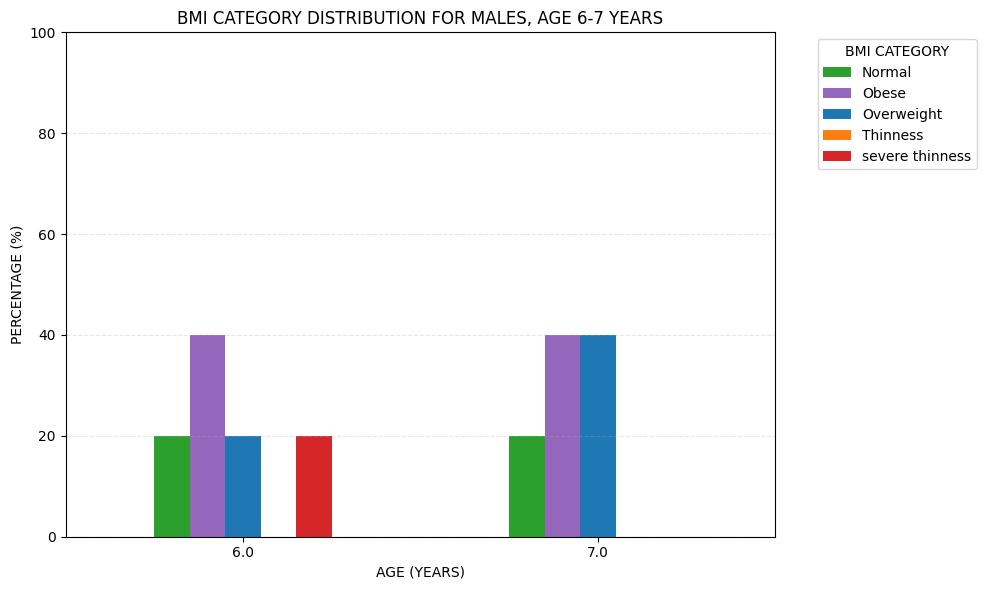

In [ ]:
# Plot grouped bar chart for boys in uturu dataset
ax  = male_df.plot(
    kind = "bar",
    figsize= (10, 6),
    color = [color_order[col] for col in male_df.columns]
)

plt.ylabel("PERCENTAGE (%)")
plt.xlabel("AGE (YEARS)")
plt.title("BMI CATEGORY DISTRIBUTION FOR MALES, AGE 6-7 YEARS")
plt.legend(title = "BMI CATEGORY", bbox_to_anchor=(1.05,1), loc = "upper left")
plt.ylim(0, 100 )
plt.xticks(rotation= 0 )
plt.grid(axis= "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract Uturu female data for ages 6-7 years
female_df = df.xs("F",level="SEX")
female_df = female_df.loc[[6,7]]

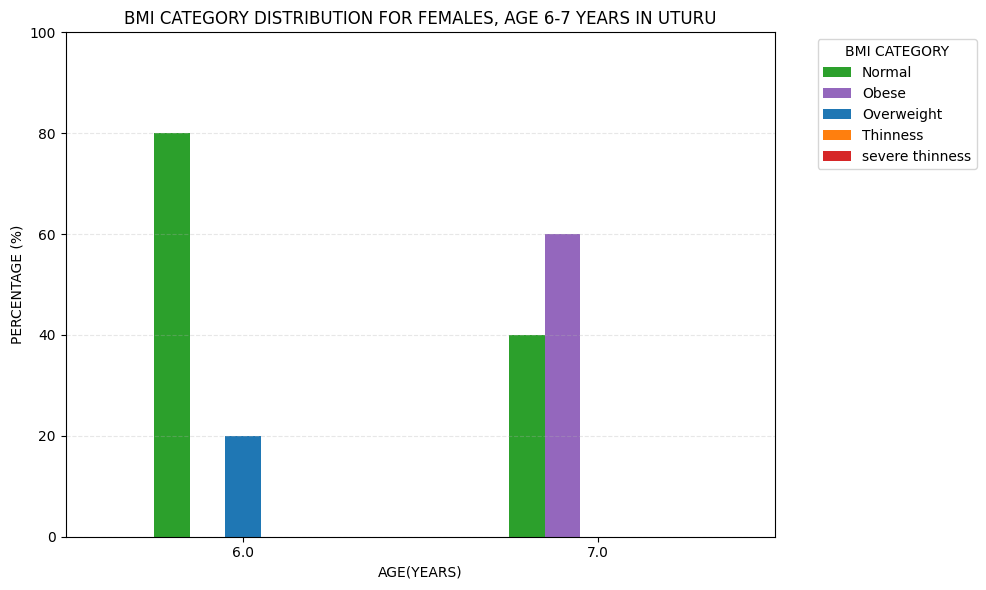

In [ ]:
# Plot grouped bar chart for girls in uturu dataset

ax = female_df.plot(
    kind = "bar",
    figsize=(10, 6 ),
    color = [color_order[col]for col in female_df.columns]
)
plt.ylabel("PERCENTAGE (%)")
plt.xlabel("AGE(YEARS)")
plt.title("BMI CATEGORY DISTRIBUTION FOR FEMALES, AGE 6-7 YEARS IN UTURU")
plt.legend(title = "BMI CATEGORY", bbox_to_anchor=(1.05,1), loc= "upper left")
plt.ylim(0,100)
plt.xticks(rotation = 0)
plt.grid(axis= "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract nhanes male data for ages 8-11 years
male_dt = dt.xs("M", level= "SEX")
male_dt = male_dt.loc[[8,9,10,11]]

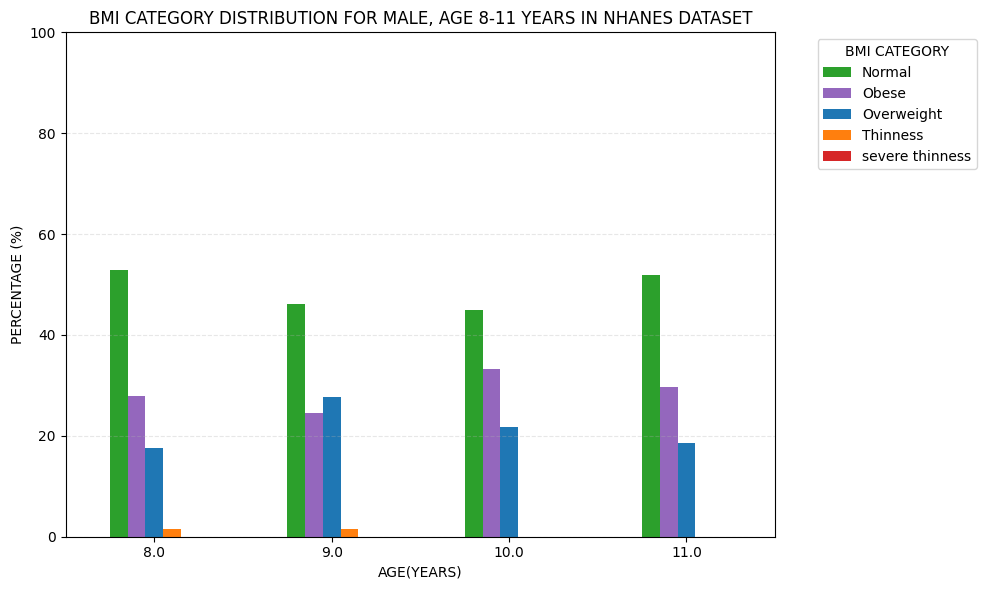

In [ ]:
# Plot grouped bar chart for boys in nhanes dataset
ax = male_dt.plot(
    kind = "bar",
    figsize=(10, 6 ),
    color = [color_order[col]for col in male_dt.columns]
)
plt.ylabel("PERCENTAGE (%)")
plt.xlabel("AGE(YEARS)")
plt.title("BMI CATEGORY DISTRIBUTION FOR MALE, AGE 8-11 YEARS IN NHANES DATASET")
plt.legend(title = "BMI CATEGORY", bbox_to_anchor=(1.05,1), loc= "upper left")
plt.ylim(0,100)
plt.xticks(rotation = 0)
plt.grid(axis= "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract nhanes female data for ages 8-11 years

female_dt = dt.xs("F", level = "SEX")
female_dt = female_dt.loc[[8,9,10,11]]

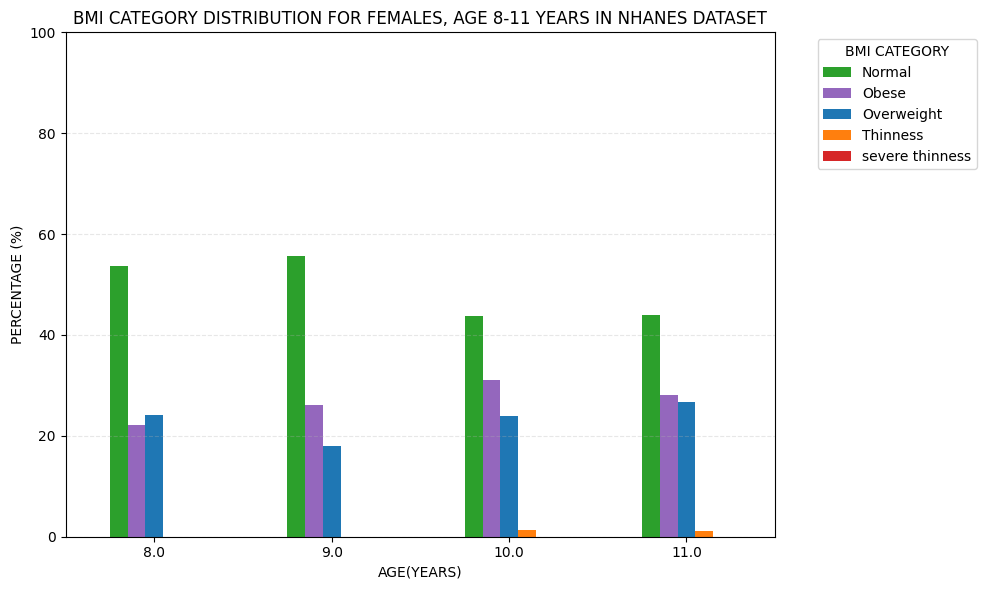

In [ ]:
# Plot grouped bar chart for girls in nhanes dataset
ax = female_dt.plot(
    kind = "bar",
    figsize=(10, 6 ),
    color = [color_order[col]for col in male_dt.columns]
)
plt.ylabel("PERCENTAGE (%)")
plt.xlabel("AGE(YEARS)")
plt.title("BMI CATEGORY DISTRIBUTION FOR FEMALES, AGE 8-11 YEARS IN NHANES DATASET")
plt.legend(title = "BMI CATEGORY", bbox_to_anchor=(1.05,1), loc= "upper left")
plt.ylim(0,100)
plt.xticks(rotation = 0)
plt.grid(axis= "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract Uturu male data for ages 8-11 years
male_df = df.xs("M", level = "SEX")
male_df = male_df.loc[[8,9,10,11]]

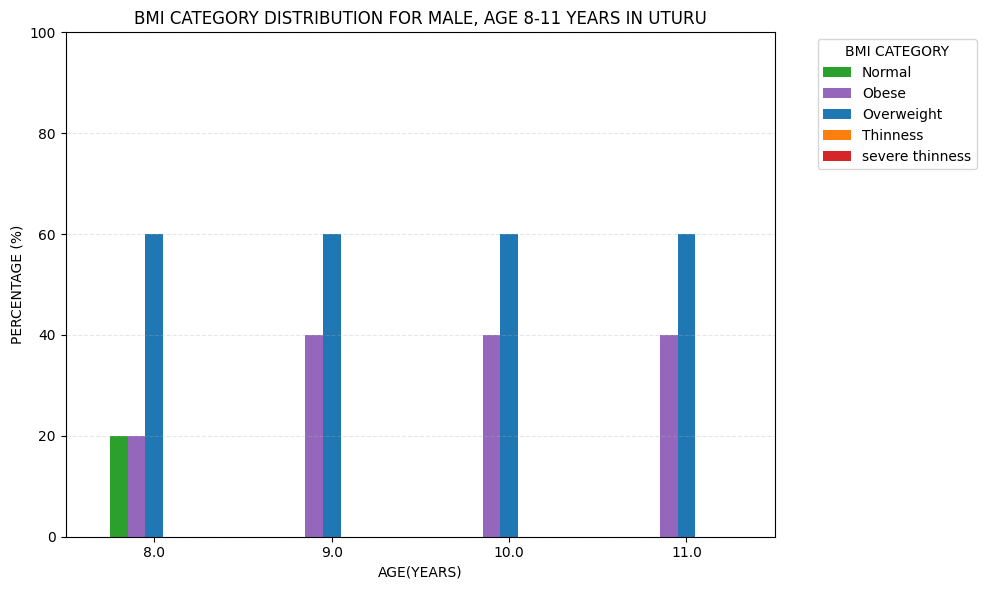

In [ ]:
# Plot grouped bar chart for boys in uturu dataset

ax = male_df.plot(
    kind = "bar",
    figsize=(10, 6 ),
    color = [color_order[col]for col in male_df.columns]
)
plt.ylabel("PERCENTAGE (%)")
plt.xlabel("AGE(YEARS)")
plt.title("BMI CATEGORY DISTRIBUTION FOR MALE, AGE 8-11 YEARS IN UTURU")
plt.legend(title = "BMI CATEGORY", bbox_to_anchor=(1.05,1), loc= "upper left")
plt.ylim(0,100)
plt.xticks(rotation = 0)
plt.grid(axis= "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract Uturu female data for ages 8-11 years
female_df = df.xs("F",level= "SEX")
female_df = female_df.loc[[8,9,10,11]]

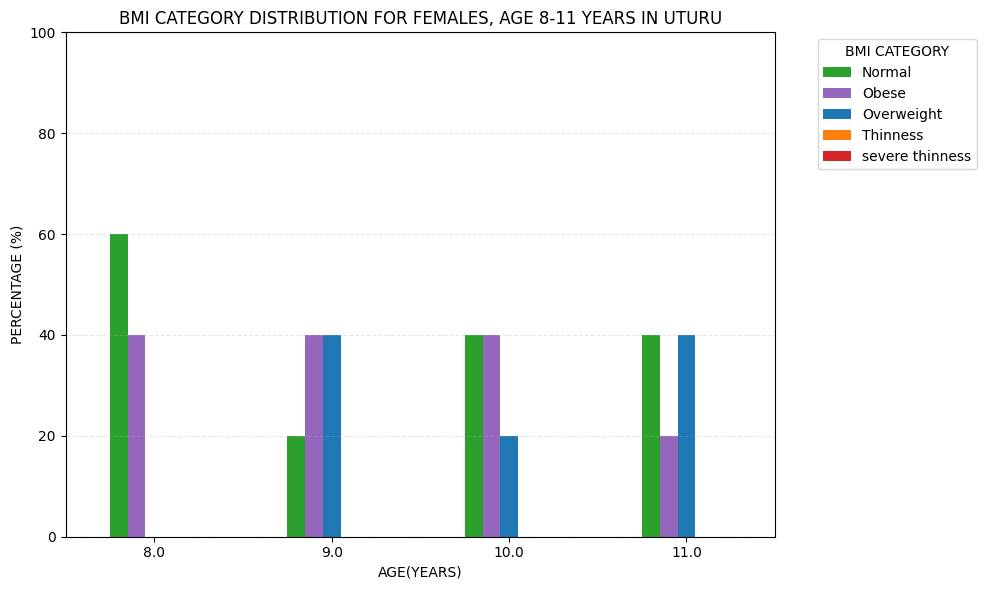

In [ ]:
# Plot grouped bar chart for girls in uturu dataset
ax = female_df.plot(
    kind = "bar",
    figsize=(10, 6 ),
    color = [color_order[col]for col in female_df.columns]
)
plt.ylabel("PERCENTAGE (%)")
plt.xlabel("AGE(YEARS)")
plt.title("BMI CATEGORY DISTRIBUTION FOR FEMALES, AGE 8-11 YEARS IN UTURU")
plt.legend(title = "BMI CATEGORY", bbox_to_anchor=(1.05,1), loc= "upper left")
plt.ylim(0,100)
plt.xticks(rotation = 0)
plt.grid(axis= "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract nhanes male data for ages 12-15 years
male_dt = dt.xs("M", level= "SEX")
male_dt =male_dt.loc[[12,13,14,15]]

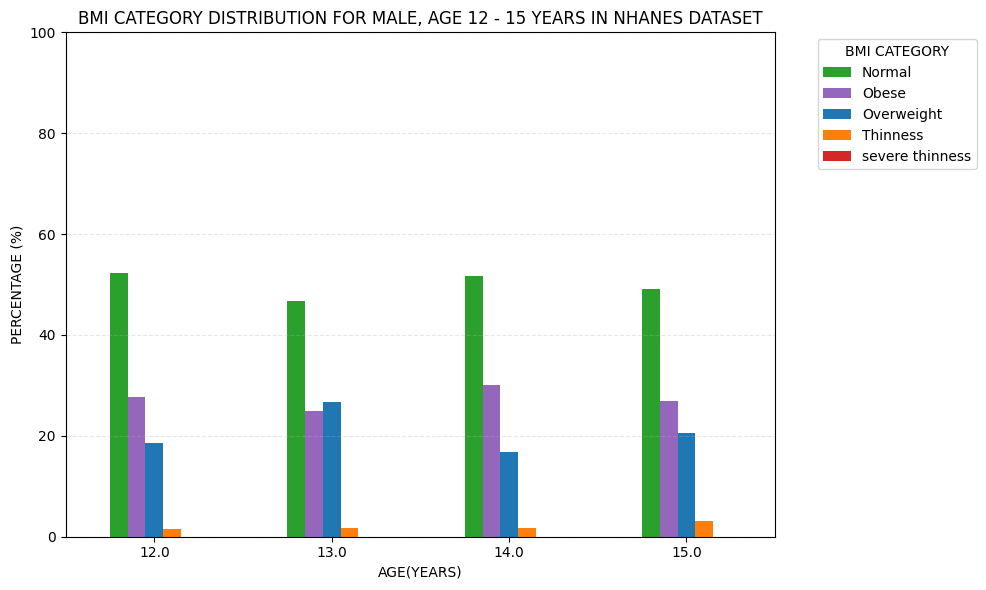

In [ ]:
# Plot grouped bar chart for boys in nhanes dataset
ax = male_dt.plot(
    kind = "bar",
    figsize=(10, 6 ),
    color = [color_order[col]for col in male_dt.columns]
)
plt.ylabel("PERCENTAGE (%)")
plt.xlabel("AGE(YEARS)")
plt.title("BMI CATEGORY DISTRIBUTION FOR MALE, AGE 12 - 15 YEARS IN NHANES DATASET")
plt.legend(title = "BMI CATEGORY", bbox_to_anchor=(1.05,1), loc= "upper left")
plt.ylim(0,100)
plt.xticks(rotation = 0)
plt.grid(axis= "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract nhanes female data for ages 12-15 years
female_dt = dt.xs("F",level= "SEX")
female_dt = female_dt.loc[[12,13,14,15]]

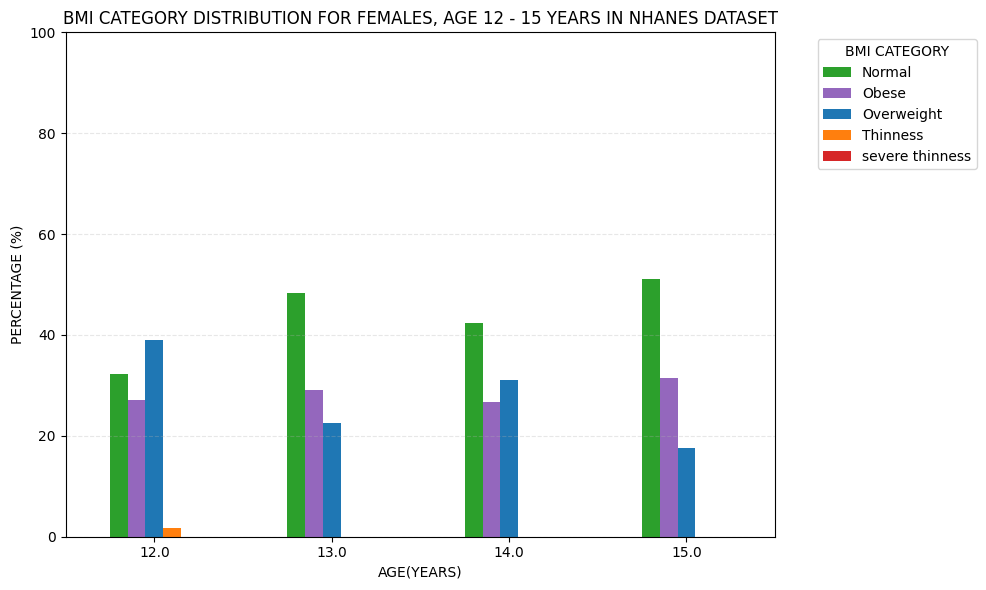

In [ ]:
# Plot grouped bar chart for girls in nhanes dataset

ax = female_dt.plot(
    kind = "bar",
    figsize=(10, 6 ),
    color = [color_order[col]for col in female_dt.columns]
)
plt.ylabel("PERCENTAGE (%)")
plt.xlabel("AGE(YEARS)")
plt.title("BMI CATEGORY DISTRIBUTION FOR FEMALES, AGE 12 - 15 YEARS IN NHANES DATASET")
plt.legend(title = "BMI CATEGORY", bbox_to_anchor=(1.05,1), loc= "upper left")
plt.ylim(0,100)
plt.xticks(rotation = 0)
plt.grid(axis= "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract Uturu male data for ages 12 - 15 years
male_df = df.xs("M", level = "SEX")
male_df = male_df.loc[[12,13,14,15]]

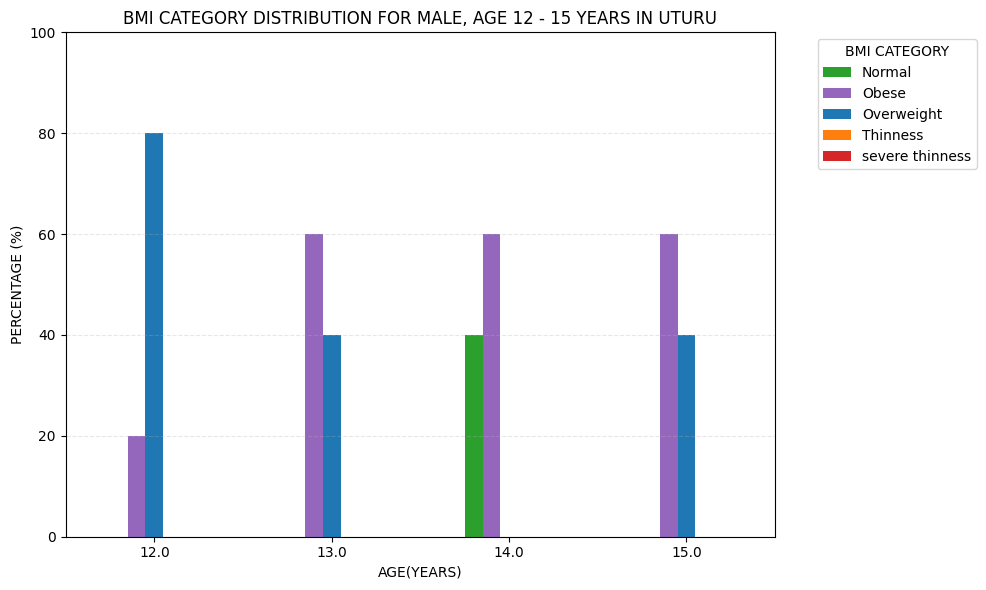

In [ ]:
# Plot grouped bar chart for boys in uturu dataset

ax =male_df.plot(
    kind = "bar",
    figsize=(10, 6 ),
    color = [color_order[col]for col in male_df.columns]
)
plt.ylabel("PERCENTAGE (%)")
plt.xlabel("AGE(YEARS)")
plt.title("BMI CATEGORY DISTRIBUTION FOR MALE, AGE 12 - 15 YEARS IN UTURU")
plt.legend(title = "BMI CATEGORY", bbox_to_anchor=(1.05,1), loc= "upper left")
plt.ylim(0,100)
plt.xticks(rotation = 0)
plt.grid(axis= "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract Uturu male data for ages 12 - 15 years
female_df = df.xs("F", level = "SEX")
female_df = female_df.loc[[12,13,14,15]]

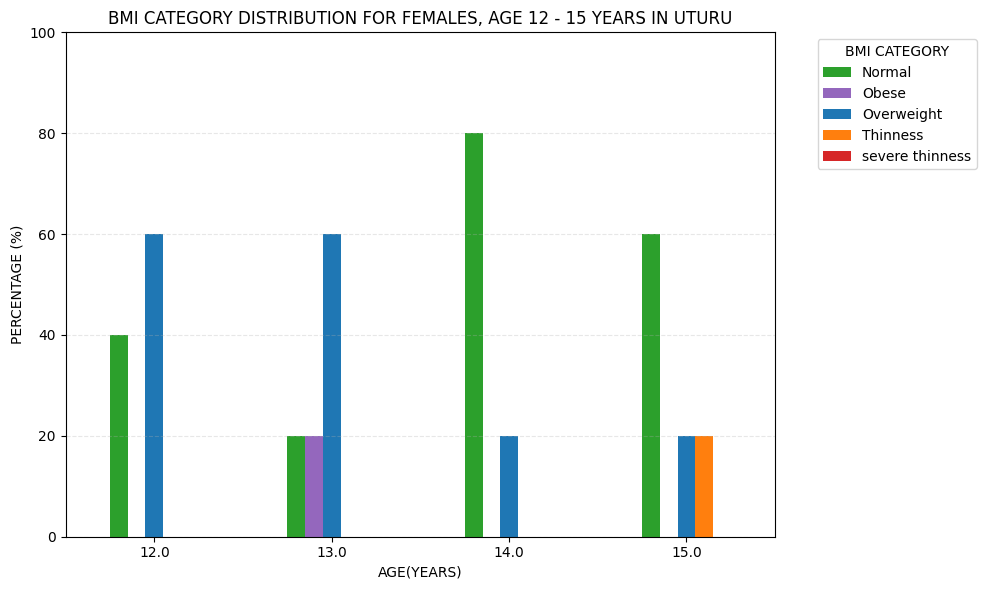

In [ ]:
# Plot grouped bar chart for girls in uturu dataset
ax = female_df.plot(
    kind = "bar",
    figsize=(10, 6 ),
    color = [color_order[col]for col in female_df.columns]
)
plt.ylabel("PERCENTAGE (%)")
plt.xlabel("AGE(YEARS)")
plt.title("BMI CATEGORY DISTRIBUTION FOR FEMALES, AGE 12 - 15 YEARS IN UTURU")
plt.legend(title = "BMI CATEGORY", bbox_to_anchor=(1.05,1), loc= "upper left")
plt.ylim(0,100)
plt.xticks(rotation = 0)
plt.grid(axis= "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract nhanes male data for ages 16 - 19  years

male_dt = dt.xs("M", level = "SEX")
male_dt = male_dt.loc[[16,17,18,19]]

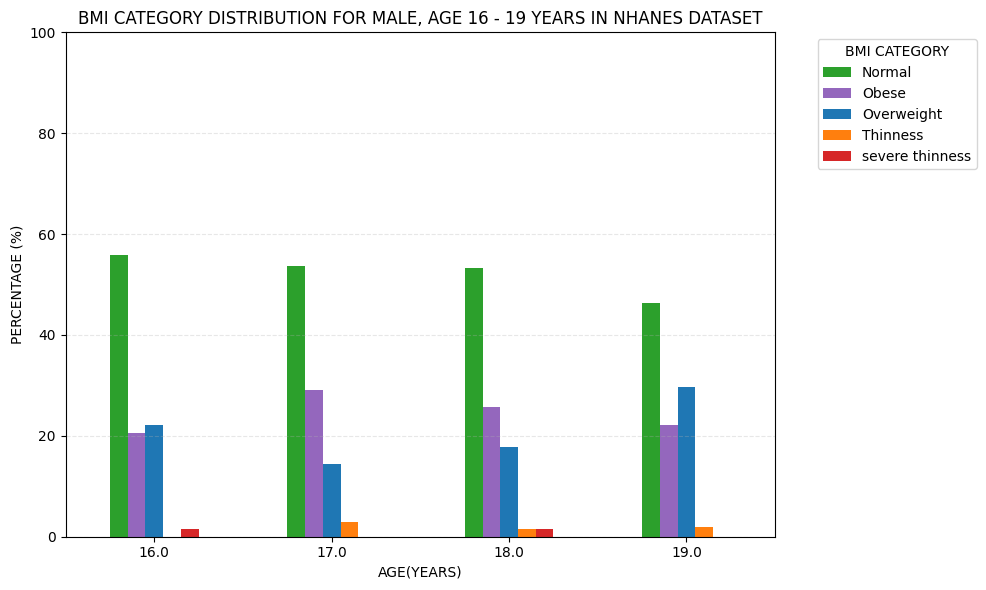

In [ ]:
# Plot grouped bar chart for boys in nhanes dataset

ax = male_dt.plot(
    kind = "bar",
    figsize=(10, 6 ),
    color = [color_order[col]for col in male_dt.columns]
)
plt.ylabel("PERCENTAGE (%)")
plt.xlabel("AGE(YEARS)")
plt.title("BMI CATEGORY DISTRIBUTION FOR MALE, AGE 16 - 19 YEARS IN NHANES DATASET")
plt.legend(title = "BMI CATEGORY", bbox_to_anchor=(1.05,1), loc= "upper left")
plt.ylim(0,100)
plt.xticks(rotation = 0)
plt.grid(axis= "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract nhanes female data for ages 16 - 19 years

female_dt = dt.xs("F", level = "SEX")
female_dt = female_dt.loc[[16,17,18,19]]

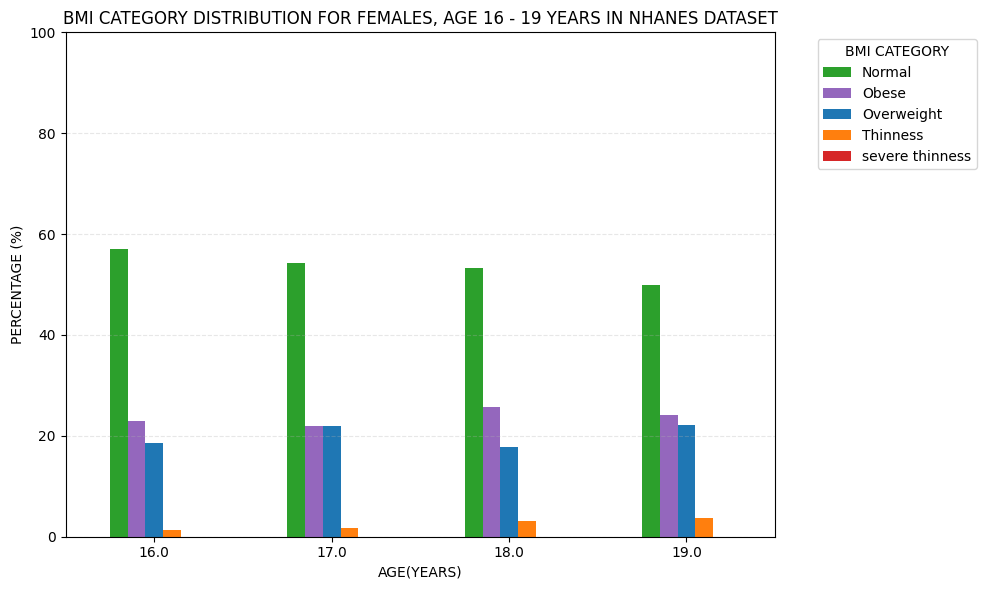

In [ ]:
# Plot grouped bar chart for girls in nhanes dataset
ax = female_dt.plot(
    kind = "bar",
    figsize=(10, 6 ),
    color = [color_order[col]for col in female_dt.columns]
)
plt.ylabel("PERCENTAGE (%)")
plt.xlabel("AGE(YEARS)")
plt.title("BMI CATEGORY DISTRIBUTION FOR FEMALES, AGE 16 - 19 YEARS IN NHANES DATASET")
plt.legend(title = "BMI CATEGORY", bbox_to_anchor=(1.05,1), loc= "upper left")
plt.ylim(0,100)
plt.xticks(rotation = 0)
plt.grid(axis= "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract Uturu male data for ages 16 - 19 years
male_df = df.xs("M", level = "SEX")
male_df = male_df.loc[[16,17,18,19]]

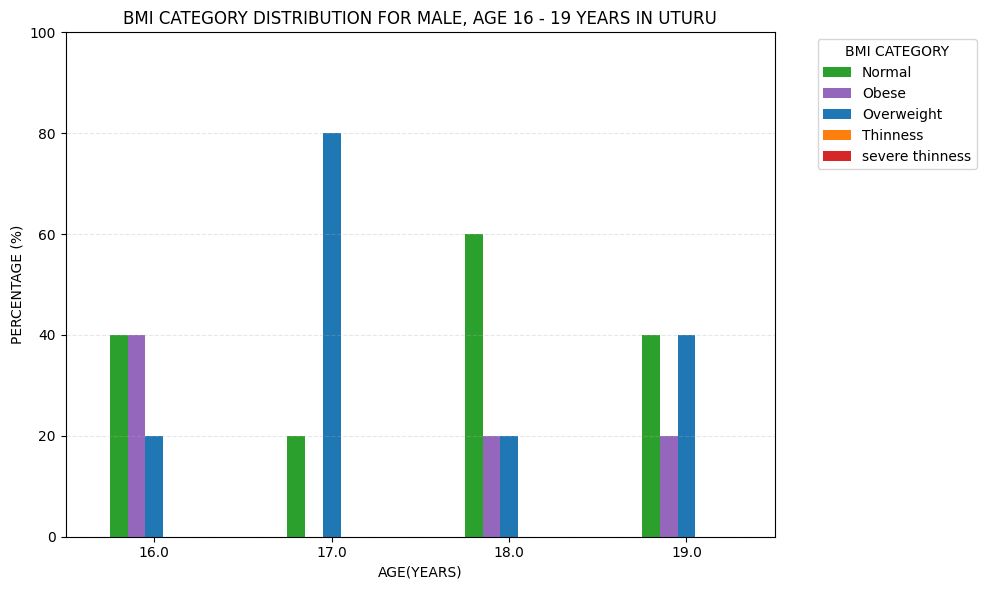

In [ ]:
# Plot grouped bar chart for boys in uturu dataset
ax = male_df.plot(
    kind = "bar",
    figsize=(10, 6 ),
    color = [color_order[col]for col in male_df.columns]
)
plt.ylabel("PERCENTAGE (%)")
plt.xlabel("AGE(YEARS)")
plt.title("BMI CATEGORY DISTRIBUTION FOR MALE, AGE 16 - 19 YEARS IN UTURU")
plt.legend(title = "BMI CATEGORY", bbox_to_anchor=(1.05,1), loc= "upper left")
plt.ylim(0,100)
plt.xticks(rotation = 0)
plt.grid(axis= "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract Uturu female data for ages 16 - 19  years
female_df = df.xs("F", level = "SEX")
female_df = female_df.loc[[16,17,18,19]]

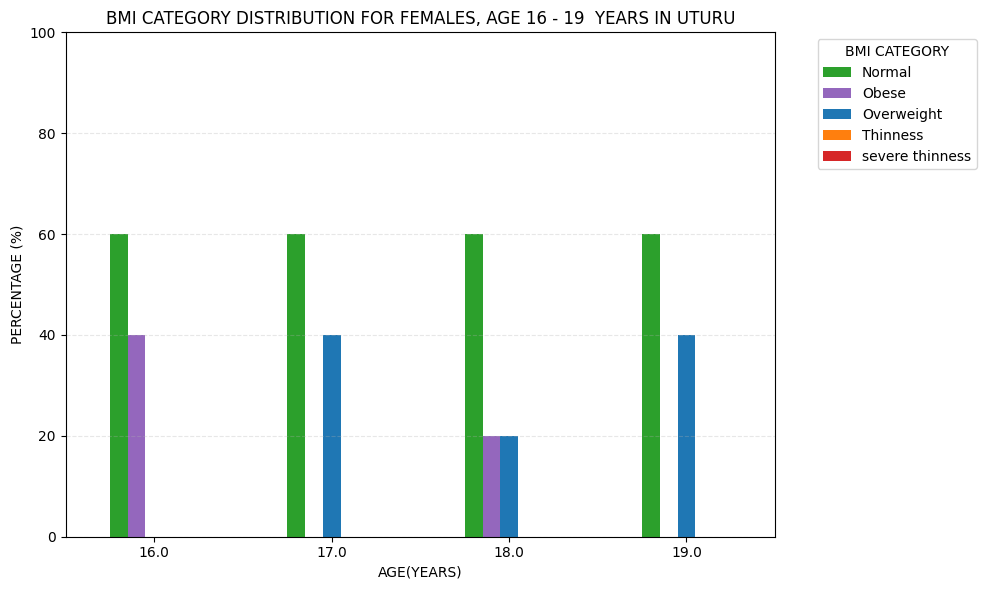

In [ ]:
# Plot grouped bar chart for girls in uturu dataset

ax = female_df.plot(
    kind = "bar",
    figsize=(10, 6 ),
    color = [color_order[col]for col in female_df.columns]
)
plt.ylabel("PERCENTAGE (%)")
plt.xlabel("AGE(YEARS)")
plt.title("BMI CATEGORY DISTRIBUTION FOR FEMALES, AGE 16 - 19  YEARS IN UTURU")
plt.legend(title = "BMI CATEGORY", bbox_to_anchor=(1.05,1), loc= "upper left")
plt.ylim(0,100)
plt.xticks(rotation = 0)
plt.grid(axis= "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Count the number of observations by sex in the uturu dataset
count = uturu_final["SEX"].value_counts()



In [ ]:
df  #  Display the uturu dataset

BMI_CATEGORY   Normal  Obese  Overweight  Thinness  severe thinness
AGE_YEARS SEX                                                      
6.0       F      80.0    0.0        20.0       0.0              0.0
          M      20.0   40.0        20.0       0.0             20.0
7.0       F      40.0   60.0         0.0       0.0              0.0
          M      20.0   40.0        40.0       0.0              0.0
8.0       F      60.0   40.0         0.0       0.0              0.0
          M      20.0   20.0        60.0       0.0              0.0
9.0       F      20.0   40.0        40.0       0.0              0.0
          M       0.0   40.0        60.0       0.0              0.0
10.0      F      40.0   40.0        20.0       0.0              0.0
          M       0.0   40.0        60.0       0.0              0.0
11.0      F      40.0   20.0        40.0       0.0              0.0
          M       0.0   40.0        60.0       0.0              0.0
12.0      F      40.0    0.0        60.0       0.0              0.0
          M       0.0   20.0        80.0       0.0              0.0
13.0      F      20.0   20.0        60.0       0.0              0.0
          M       0.0   60.0        40.0       0.0              0.0
14.0      F      80.0    0.0        20.0       0.0              0.0
          M      40.0   60.0         0.0       0.0              0.0
15.0      F      60.0    0.0        20.0      20.0              0.0
          M       0.0   60.0        40.0       0.0              0.0
16.0      F      60.0   40.0         0.0       0.0              0.0
          M      40.0   40.0        20.0       0.0              0.0
17.0      F      60.0    0.0        40.0       0.0              0.0
          M      20.0    0.0        80.0       0.0              0.0
18.0      F      60.0   20.0        20.0       0.0              0.0
          M      60.0   20.0        20.0       0.0              0.0
19.0      F      60.0    0.0        40.0       0.0              0.0
          M      40.0   20.0        40.0       0.0              0.0

In [ ]:
df.columns  # Display the uturu dataset

Index(['Normal', 'Obese', 'Overweight', 'Thinness', 'severe thinness'], dtype='object', name='BMI_CATEGORY')

In [ ]:
df = df.reset_index()  #  Convert the multi-index to columns for the uturu dataset

In [ ]:
dt= dt.reset_index()   #  Convert the multi-index to columns for the nhanes dataset

In [ ]:
df.columns  # Display  the uturu dataset columns

Index(['AGE_YEARS', 'SEX', 'Normal', 'Obese', 'Overweight', 'Thinness',
       'severe thinness'],
      dtype='object', name='BMI_CATEGORY')

In [ ]:
#  Reshape the uturu dataset from wide to long for plotting and analysis
df= df.reset_index()
df_long = df.melt(
    id_vars= ["AGE_YEARS","SEX"],
    value_vars=["Normal","Obese","Overweight","Thinness","severe thinness"],
    var_name="BMI_CATEGORY",
    value_name= "percent"

)

In [ ]:
df # Display the uturu dataset

BMI_CATEGORY,index,AGE_YEARS,SEX,Normal,Obese,Overweight,Thinness,severe thinness
0,0,6.0,F,80.0,0.0,20.0,0.0,0.0
1,1,6.0,M,20.0,40.0,20.0,0.0,20.0
2,2,7.0,F,40.0,60.0,0.0,0.0,0.0
3,3,7.0,M,20.0,40.0,40.0,0.0,0.0
4,4,8.0,F,60.0,40.0,0.0,0.0,0.0
5,5,8.0,M,20.0,20.0,60.0,0.0,0.0
6,6,9.0,F,20.0,40.0,40.0,0.0,0.0
7,7,9.0,M,0.0,40.0,60.0,0.0,0.0
8,8,10.0,F,40.0,40.0,20.0,0.0,0.0
9,9,10.0,M,0.0,40.0,60.0,0.0,0.0


In [ ]:
#  Reshape the nhanes dataset from wide to long for plotting and analysis

dt_long = dt.melt(
    id_vars=["AGE_YEARS","SEX"],
    value_vars=["Normal","Obese","Overweight","Thinness","severe thinness"],
    var_name= "BMI_CATEGORY",
    value_name= "percent"

)

In [ ]:
# Remove the columns index name for cleaner display in both uturu and  NHANES datasets
df.columns.name = None
dt.columns.name= None

In [ ]:
df # Display the uturu dataset

,index,AGE_YEARS,SEX,Normal,Obese,Overweight,Thinness,severe thinness
0,0,6.0,F,80.0,0.0,20.0,0.0,0.0
1,1,6.0,M,20.0,40.0,20.0,0.0,20.0
2,2,7.0,F,40.0,60.0,0.0,0.0,0.0
3,3,7.0,M,20.0,40.0,40.0,0.0,0.0
4,4,8.0,F,60.0,40.0,0.0,0.0,0.0
5,5,8.0,M,20.0,20.0,60.0,0.0,0.0
6,6,9.0,F,20.0,40.0,40.0,0.0,0.0
7,7,9.0,M,0.0,40.0,60.0,0.0,0.0
8,8,10.0,F,40.0,40.0,20.0,0.0,0.0
9,9,10.0,M,0.0,40.0,60.0,0.0,0.0


In [ ]:
# Drop the redundant "index" column generated during index reset

df.drop(columns="index")

,AGE_YEARS,SEX,Normal,Obese,Overweight,Thinness,severe thinness
0,6.0,F,80.0,0.0,20.0,0.0,0.0
1,6.0,M,20.0,40.0,20.0,0.0,20.0
2,7.0,F,40.0,60.0,0.0,0.0,0.0
3,7.0,M,20.0,40.0,40.0,0.0,0.0
4,8.0,F,60.0,40.0,0.0,0.0,0.0
5,8.0,M,20.0,20.0,60.0,0.0,0.0
6,9.0,F,20.0,40.0,40.0,0.0,0.0
7,9.0,M,0.0,40.0,60.0,0.0,0.0
8,10.0,F,40.0,40.0,20.0,0.0,0.0
9,10.0,M,0.0,40.0,60.0,0.0,0.0


In [ ]:
dt # Display the nhanes dataset

,AGE_YEARS,SEX,Normal,Obese,Overweight,Thinness,severe thinness
0,8.0,F,53.7,22.2,24.1,0.0,0.0
1,8.0,M,52.9,27.9,17.6,1.5,0.0
2,9.0,F,55.7,26.2,18.0,0.0,0.0
3,9.0,M,46.2,24.6,27.7,1.5,0.0
4,10.0,F,43.7,31.0,23.9,1.4,0.0
5,10.0,M,44.9,33.3,21.8,0.0,0.0
6,11.0,F,43.9,28.0,26.8,1.2,0.0
7,11.0,M,51.9,29.6,18.5,0.0,0.0
8,12.0,F,32.2,27.1,39.0,1.7,0.0
9,12.0,M,52.3,27.7,18.5,1.5,0.0


In [ ]:
#

def monte_carlo_test(sample1_counts, sample2_counts, total_sample1, total_sample2, all_categories, num_simulations=10000):
    """
    Performs a permutation-based Monte Carlo test for comparing proportions.

    Args:
        sample1_counts (dict): A dictionary where keys are categories and values are counts for sample 1.
        sample2_counts (dict): A dictionary where keys are categories and values are counts for sample 2.
        total_sample1 (int): Total number of observations in sample 1.
        total_sample2 (int): Total number of observations in sample 2.
        all_categories (list): A list of all possible BMI categories to consider.
        num_simulations (int): Number of Monte Carlo simulations to run.

    Returns:
        dict: A dictionary containing p-values and comments for each category.
    """
    results = {}

    for category in all_categories:
        count1 = sample1_counts.get(category, 0)
        count2 = sample2_counts.get(category, 0)

        # Observed difference in proportion
        obs_prop1 = count1 / total_sample1 if total_sample1 > 0 else 0
        obs_prop2 = count2 / total_sample2 if total_sample2 > 0 else 0
        observed_diff = abs(obs_prop1 - obs_prop2)

        if total_sample1 == 0 and total_sample2 == 0:
            results[category] = {"p_value": np.nan, "comment": f"No data for category '{category}' in either sample.", "obs_prop_uturu": obs_prop1, "obs_prop_nhanes": obs_prop2}
            continue
        elif total_sample1 == 0:
             results[category] = {"p_value": np.nan, "comment": f"No data for category '{category}' in Uturu sample.", "obs_prop_uturu": obs_prop1, "obs_prop_nhanes": obs_prop2}
             continue
        elif total_sample2 == 0:
            results[category] = {"p_value": np.nan, "comment": f"No data for category '{category}' in NHANES sample.", "obs_prop_uturu": obs_prop1, "obs_prop_nhanes": obs_prop2}
            continue

        # Combined pool for simulations
        combined_total = total_sample1 + total_sample2
        combined_category_count = count1 + count2

        if combined_category_count == 0:
            results[category] = {
                "p_value": 1.0,
                "comment": f"No occurrences of '{category}' in either sample. P-value = 1.0. No statistically significant difference.",
                "obs_prop_uturu": obs_prop1, "obs_prop_nhanes": obs_prop2
            }
            continue

        simulated_diffs = []
        for _ in range(num_simulations):
            # Draw 'total_sample1' items from the combined pool
            # The number of 'successes' (items from the category) in this draw is `x`
            # The total number of items is `combined_total`
            # The number of 'successes' in the population is `combined_category_count`
            # The number of items drawn is `total_sample1`
            sim_count1 = np.random.hypergeometric(
                ngood=combined_category_count,
                nbad=combined_total - combined_category_count,
                nsample=total_sample1
            )
            sim_count2 = combined_category_count - sim_count1

            sim_prop1 = sim_count1 / total_sample1
            sim_prop2 = sim_count2 / total_sample2
            simulated_diffs.append(abs(sim_prop1 - sim_prop2))

        p_value = np.sum(np.array(simulated_diffs) >= observed_diff) / num_simulations

        comment = f"Observed Proportion (Uturu): {obs_prop1:.4f}, Observed Proportion (NHANES): {obs_prop2:.4f}. "
        if p_value < 0.05:
            comment += "There is a statistically significant difference in the proportion of this BMI category between Uturu and NHANES."
        else:
            comment += "There is no statistically significant difference in the proportion of this BMI category between Uturu and NHANES."

        results[category] = {"p_value": p_value, "comment": comment, "obs_prop_uturu": obs_prop1, "obs_prop_nhanes": obs_prop2}
    return results

# Define age groups and all BMI categories
age_groups = {
    "8-11": range(8, 12),
    "12-15": range(12, 16),
    "16-19": range(16, 20)
}
sexes = ["M", "F"]
all_categories = ["Normal", "Obese", "Overweight", "Thinness", "severe thinness"]

print("Performing Monte Carlo tests for BMI category proportions by age group and sex:")

all_monte_carlo_results = []

for age_label, ages in age_groups.items():
    for sex in sexes:
        # Filter data for the current age group and sex
        uturu_filtered = uturu_final[
            (uturu_final["AGE_YEARS"].isin(ages)) & (uturu_final["SEX"] == sex)
        ]
        nhanes_filtered = nhanes_final[
            (nhanes_final["AGE_YEARS"].isin(ages)) & (nhanes_final["SEX"] == sex)
        ]

        # Get counts for each BMI category
        uturu_counts = uturu_filtered["BMI_CATEGORY"].value_counts().to_dict()
        nhanes_counts = nhanes_filtered["BMI_CATEGORY"].value_counts().to_dict()

        total_uturu = len(uturu_filtered)
        total_nhanes = len(nhanes_filtered)

        # Perform Monte Carlo test
        test_results = monte_carlo_test(
            uturu_counts, nhanes_counts, total_uturu, total_nhanes, all_categories
        )

        for category, result in test_results.items():
            all_monte_carlo_results.append({
                "Age Group": age_label,
                "Sex": sex,
                "BMI Category": category,
                "Uturu Proportion": result["obs_prop_uturu"],
                "NHANES Proportion": result["obs_prop_nhanes"],
                "P-value": result["p_value"]
            })

# Convert results to a DataFrame
mc_results_df = pd.DataFrame(all_monte_carlo_results)

# Drop rows where P-value is NaN (no data in either sample for that category/group)
mc_results_df.dropna(subset=["P-value"], inplace=True)

# Apply Bonferroni Correction
alpha = 0.05
num_comparisons = len(mc_results_df) # Total number of tests performed
bonferroni_alpha = alpha / num_comparisons

def format_p(p_value):
  if p < 0.001:
    return "<0.001"
  else:
    return f"{p:.4f}"


mc_results_df["Bonferroni_Corrected_P_value"] = mc_results_df["P-value"].apply(lambda p: min(p * num_comparisons, 1.0))
mc_results_df["Significant_After_Bonferroni"] = mc_results_df["P-value"] < bonferroni_alpha

print(f"\nBonferroni Correction Applied (Alpha = {alpha}, Number of comparisons = {num_comparisons}, Adjusted Alpha = {bonferroni_alpha:.6f}):\n")
display(mc_results_df)

Performing Monte Carlo tests for BMI category proportions by age group and sex:

Bonferroni Correction Applied (Alpha = 0.05, Number of comparisons = 30, Adjusted Alpha = 0.001667):



,Age Group,Sex,BMI Category,Uturu Proportion,NHANES Proportion,P-value,Bonferroni_Corrected_P_value,Significant_After_Bonferroni
0,8-11,M,Normal,0.05,0.486792,0.0000,0.000,True
1,8-11,M,Obese,0.35,0.290566,0.6226,1.000,False
2,8-11,M,Overweight,0.60,0.215094,0.0005,0.015,True
3,8-11,M,Thinness,0.00,0.007547,1.0000,1.000,False
4,8-11,M,severe thinness,0.00,0.000000,1.0000,1.000,False
5,8-11,F,Normal,0.40,0.485075,0.5030,1.000,False
6,8-11,F,Obese,0.35,0.272388,0.5939,1.000,False
7,8-11,F,Overweight,0.25,0.235075,1.0000,1.000,False
8,8-11,F,Thinness,0.00,0.007463,1.0000,1.000,False
9,8-11,F,severe thinness,0.00,0.000000,1.0000,1.000,False


In [ ]:
# Display the first 30 rows of Monte Carlo test results for inspection
mc_results_df.head(30)

,Age Group,Sex,BMI Category,Uturu Proportion,NHANES Proportion,P-value,Bonferroni_Corrected_P_value,Significant_After_Bonferroni
0,8-11,M,Normal,0.05,0.486792,0.0000,0.000,True
1,8-11,M,Obese,0.35,0.290566,0.6226,1.000,False
2,8-11,M,Overweight,0.60,0.215094,0.0005,0.015,True
3,8-11,M,Thinness,0.00,0.007547,1.0000,1.000,False
4,8-11,M,severe thinness,0.00,0.000000,1.0000,1.000,False
5,8-11,F,Normal,0.40,0.485075,0.5030,1.000,False
6,8-11,F,Obese,0.35,0.272388,0.5939,1.000,False
7,8-11,F,Overweight,0.25,0.235075,1.0000,1.000,False
8,8-11,F,Thinness,0.00,0.007463,1.0000,1.000,False
9,8-11,F,severe thinness,0.00,0.000000,1.0000,1.000,False


In [ ]:
# Display the first 10 rows of the cleaned_file_sel (NHANES DATASET)

cleaned_file_sel.head(10)

,SEQN,AGE_YEARS,SEX,SBP,DBP,BMI,AGE_MONTHS
3,93706.0,18.0,M,112.0,74.0,21.5,216
4,93707.0,13.0,M,128.0,38.0,18.1,156
9,93712.0,18.0,M,112.0,68.0,19.7,216
16,93719.0,13.0,F,102.0,62.0,26.0,156
30,93733.0,11.0,F,104.0,48.0,20.1,132
32,93736.0,11.0,M,108.0,70.0,17.9,132
43,93747.0,13.0,F,106.0,70.0,22.1,156
48,93753.0,10.0,F,120.0,64.0,24.6,120
73,93778.0,19.0,F,102.0,70.0,27.4,228
74,93779.0,10.0,F,104.0,42.0,16.4,120


In [ ]:
# Display the first 10 rows of the uturu dataset

uturu.head(10)

,AGE_YEARS,SEX,WEIGHT_Kg,HEIGHT_m,SBP,DBP,BMI,AGE_MONTHS,HEIGHT_cm
0,6,M,18,0.98,114,56,18.742191,72,98.0
1,6,F,15,1.02,93,55,14.417532,72,102.0
2,6,M,15,1.06,117,55,13.349947,72,106.0
3,6,M,12,1.04,118,59,11.094675,72,104.0
4,6,F,16,1.03,94,56,15.081535,72,103.0
5,6,M,20,1.04,118,54,18.491124,72,104.0
6,6,F,21,1.12,97,58,16.741071,72,112.0
7,6,F,19,1.15,98,61,14.366730,72,115.0
8,6,M,21,1.05,120,64,19.047619,72,105.0
9,6,F,25,1.17,104,63,18.262839,72,117.0


In [ ]:
def format_p(p):
  return "<0.001" if p < 0.001 else f"{p:.3f}"

def spearman_bmi_bp(df, name):
  rho_SBP, p_SBP = spearmanr(df["BMI"],df["SBP"])
  rho_DBP, p_DBP = spearmanr(df["BMI"], df["DBP"])

  # Initialize results list with overall correlation
  results = [[ "Overall", round(rho_SBP,3), format_p(p_SBP),round(rho_DBP,3),format_p(p_DBP)]]

  #by sex
  for sex in df["SEX"].unique():
    sub = df[df["SEX"]== sex]
    r_SBP ,P_SBP_sex = spearmanr(sub["BMI"],sub["SBP"])
    r_DBP, p_DBP_sex = spearmanr(sub["BMI"], sub["DBP"])
    results.append([sex, round(r_SBP,3) , format_p(P_SBP_sex),round(r_DBP,3), format_p(p_DBP_sex)])

  table = pd.DataFrame(results, columns=["Group","SBP Rho","SBP P-value","DBP Rho","DBP P-value"])
  print(f"\n{name} - Spearman Correlation : BMI vs BP")
  print(table.to_string(index=False))
  return  table


#Run it
uturu_table = spearman_bmi_bp(uturu, "Uturu")
print(uturu_table)
nhanes_table = spearman_bmi_bp(cleaned_file_sel,"NHANES")
print(nhanes_table)


Uturu - Spearman Correlation : BMI vs BP
  Group  SBP Rho SBP P-value  DBP Rho DBP P-value
Overall    0.328      <0.001    0.259       0.002
      M    0.325       0.006    0.169       0.161
      F    0.285       0.017    0.255       0.033
     Group  SBP Rho SBP P-value  DBP Rho DBP P-value
0  Overall    0.328      <0.001    0.259       0.002
1        M    0.325       0.006    0.169       0.161
2        F    0.285       0.017    0.255       0.033

NHANES - Spearman Correlation : BMI vs BP
  Group  SBP Rho SBP P-value  DBP Rho DBP P-value
Overall    0.390      <0.001    0.175      <0.001
      M    0.466      <0.001    0.215      <0.001
      F    0.344      <0.001    0.124      <0.001
     Group  SBP Rho SBP P-value  DBP Rho DBP P-value
0  Overall    0.390      <0.001    0.175      <0.001
1        M    0.466      <0.001    0.215      <0.001
2        F    0.344      <0.001    0.124      <0.001


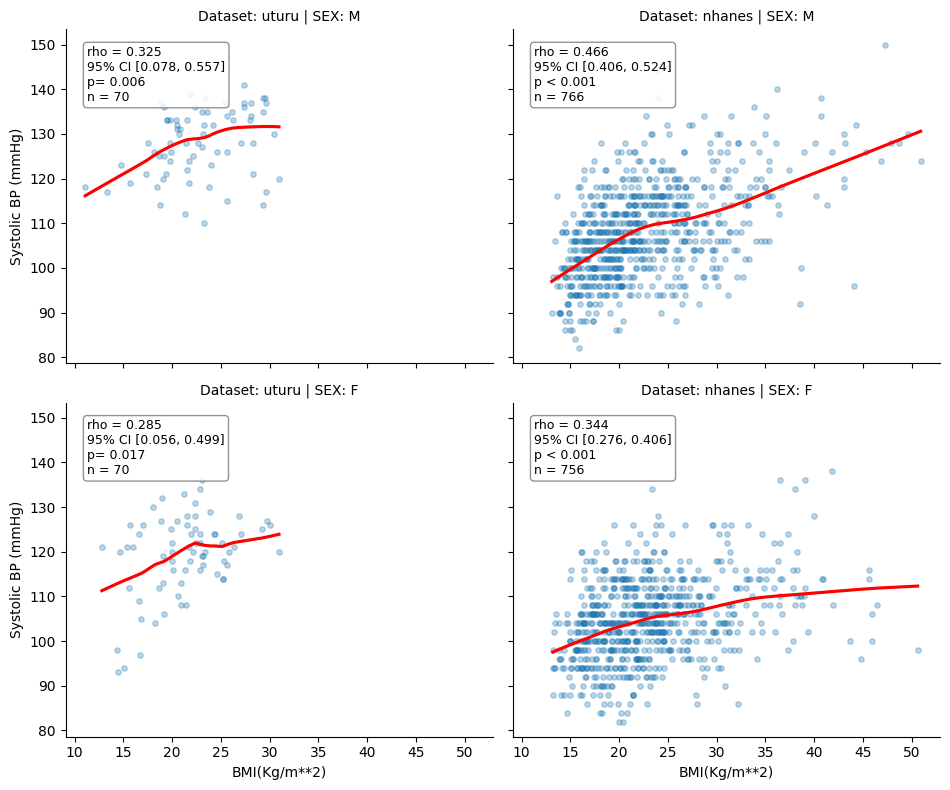

In [ ]:
import random # Added this line

def bootstrap_spearman_ci(x,y,n_boot=2000, ci=95, random_state=42):
  """Return median rho and lower/upper CI from bootstrap """
  rng = np.random.default_rng(random_state)
  n = len(x)
  boot_rhos = []

  for _  in  range(n_boot):
    idx = rng.integers(0, n, n)
    rx,ry = x[idx], y[idx]
    if np.std(rx)== 0 or np.std(ry) == 0:
      continue
    r, _ = spearmanr(rx, ry)
    boot_rhos.append(r)


  boot_rhos = np.array(boot_rhos)
  lower = np. percentile(boot_rhos,(100- ci)/2)
  upper = np.percentile(boot_rhos, 100- (100 - ci ) / 2)
  return np.median(boot_rhos), lower, upper


#Calculate rho, p, n, and 95% CI for each group

def calc_stats(df_subset):
  rho,p = spearmanr(df_subset["BMI"], df_subset["SBP"])
  median_rho, ci_low , ci_high = bootstrap_spearman_ci(df_subset["BMI"].values, df_subset["SBP"].values)
  return rho, p, len(df_subset), ci_low, ci_high



# Populate results DataFrame by applying calc_stats
results_list = []

# Uturu data
rho_m_uturu, p_m_uturu, n_m_uturu, ci_low_m_uturu, ci_high_m_uturu = calc_stats(uturu[uturu["SEX"]=="M"])
results_list.append({"dataset":"uturu","SEX": "M","rho": rho_m_uturu, "p": p_m_uturu,"n": n_m_uturu, "ci_low": ci_low_m_uturu, "ci_high": ci_high_m_uturu})

rho_f_uturu, p_f_uturu, n_f_uturu, ci_low_f_uturu, ci_high_f_uturu = calc_stats(uturu[uturu["SEX"]=="F"])
results_list.append({"dataset":"uturu","SEX": "F","rho": rho_f_uturu, "p": p_f_uturu,"n": n_f_uturu, "ci_low": ci_low_f_uturu, "ci_high": ci_high_f_uturu})

# NHANES data
rho_m_nhanes, p_m_nhanes, n_m_nhanes, ci_low_m_nhanes, ci_high_m_nhanes = calc_stats(cleaned_file_sel[cleaned_file_sel["SEX"]=="M"])
results_list.append({"dataset":"nhanes","SEX": "M","rho": rho_m_nhanes, "p": p_m_nhanes,"n": n_m_nhanes, "ci_low": ci_low_m_nhanes, "ci_high": ci_high_m_nhanes})

rho_f_nhanes, p_f_nhanes, n_f_nhanes, ci_low_f_nhanes, ci_high_f_nhanes = calc_stats(cleaned_file_sel[cleaned_file_sel["SEX"]=="F"])
results_list.append({"dataset":"nhanes","SEX": "F","rho": rho_f_nhanes, "p": p_f_nhanes,"n": n_f_nhanes, "ci_low": ci_low_f_nhanes, "ci_high": ci_high_f_nhanes})

results = pd.DataFrame(results_list)


# Prepare data for plotting
uturu_plot = uturu.copy()
uturu_plot["dataset"] = "uturu"

nhanes_plot = cleaned_file_sel.copy()
nhanes_plot["dataset"] = "nhanes"

plot_data = pd.concat([uturu_plot, nhanes_plot])


#making the 2x2  facet plot
g = sns.lmplot(
    x="BMI", y = "SBP",
    col= "dataset",
    row = "SEX",
    data = plot_data, # Pass the combined DataFrame here
    lowess = True,#lowess line
    scatter_kws= {"alpha": 0.3, "s" : 15 },
    line_kws= {"color": "red"},
    height= 4, aspect= 1.2

)

g.set_axis_labels("BMI(Kg/m**2)", "Systolic BP (mmHg)")
g.set_titles("Dataset: {col_name} | SEX: {row_name}")

#annotate each panel with rho , p , and n

for i , dataset_col in enumerate(g.col_names):   #i = 0 Uturu, i = 1 NHANES,
    for j , sex_group_row in enumerate(g.row_names): #j =0 Female, j= 1 Male in seaborn default
    #Get the result  for this panel
       row = results[(results["dataset"] == dataset_col) & (results["SEX"] == sex_group_row)]
       if row.empty:
           continue

       rho = row["rho"].values[0]
       p = row["p"].values[0]
       n = int(row["n"].values[0])
       ci_low = row["ci_low"].values[0]
       ci_high = row["ci_high"].values[0]

       p_str  = "p < 0.001" if p < 0.001 else f"p= {p:.3f}"
       text = f"rho = {rho:.3f}\n95% CI [{ci_low:.3f}, {ci_high:.3f}]\n{p_str}\nn = {n}"

       ax = g.axes[j,i]
       ax.text(0.05,0.95,text, transform= ax.transAxes, fontsize= 9, verticalalignment="top",
               bbox= dict(boxstyle= "round", facecolor= "white",alpha= 0.85, edgecolor= "gray"))


plt.tight_layout()
plt.show()

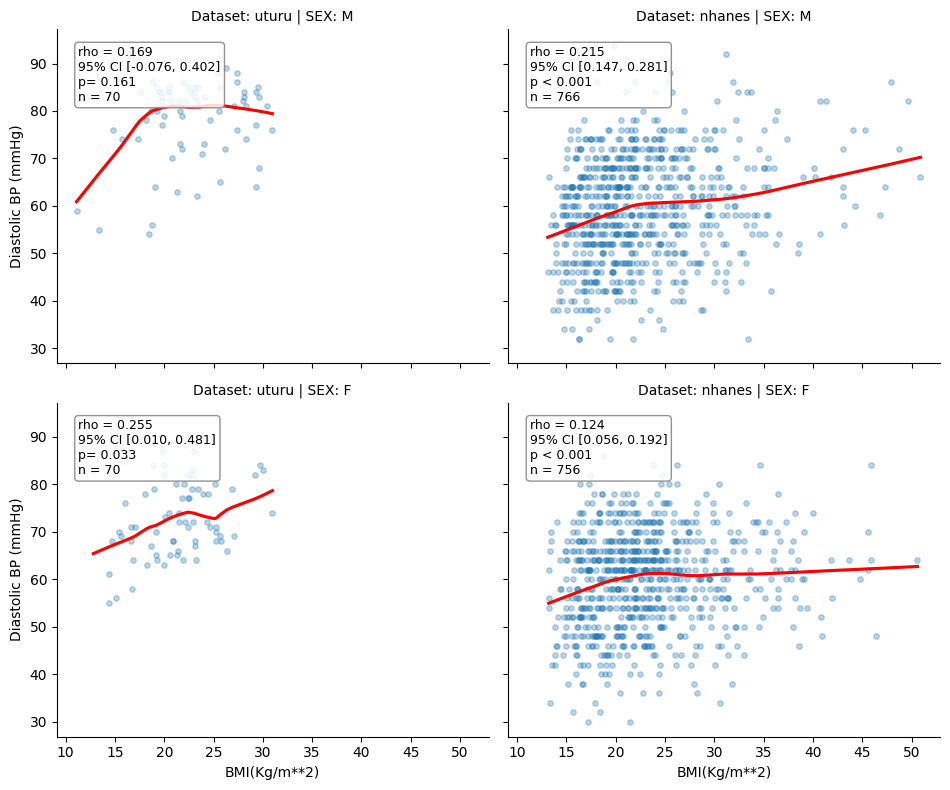

In [ ]:
import random # Added this line

def bootstrap_spearman_ci(x,y,n_boot=2000, ci=95, random_state=42):
  """Return median rho and lower/upper CI from bootstrap """
  rng = np.random.default_rng(random_state)
  n = len(x)
  boot_rhos = []

  for _  in  range(n_boot):
    idx = rng.integers(0, n, n)
    rx,ry = x[idx], y[idx]
    if np.std(rx)== 0 or np.std(ry) == 0:
      continue
    r, _ = spearmanr(rx, ry)
    boot_rhos.append(r)


  boot_rhos = np.array(boot_rhos)
  lower = np. percentile(boot_rhos,(100- ci)/2)
  upper = np.percentile(boot_rhos, 100- (100 - ci ) / 2)
  return np.median(boot_rhos), lower, upper


#Calculate rho, p, n, and 95% CI for each group

def calc_stats(df_subset):
  rho,p = spearmanr(df_subset["BMI"], df_subset["DBP"])
  median_rho, ci_low , ci_high = bootstrap_spearman_ci(df_subset["BMI"].values, df_subset["DBP"].values)
  return rho, p, len(df_subset), ci_low, ci_high



# Populate results DataFrame by applying calc_stats
results_list = []

# Uturu data
rho_m_uturu, p_m_uturu, n_m_uturu, ci_low_m_uturu, ci_high_m_uturu = calc_stats(uturu[uturu["SEX"]=="M"])
results_list.append({"dataset":"uturu","SEX": "M","rho": rho_m_uturu, "p": p_m_uturu,"n": n_m_uturu, "ci_low": ci_low_m_uturu, "ci_high": ci_high_m_uturu})

rho_f_uturu, p_f_uturu, n_f_uturu, ci_low_f_uturu, ci_high_f_uturu = calc_stats(uturu[uturu["SEX"]=="F"])
results_list.append({"dataset":"uturu","SEX": "F","rho": rho_f_uturu, "p": p_f_uturu,"n": n_f_uturu, "ci_low": ci_low_f_uturu, "ci_high": ci_high_f_uturu})

# NHANES data
rho_m_nhanes, p_m_nhanes, n_m_nhanes, ci_low_m_nhanes, ci_high_m_nhanes = calc_stats(cleaned_file_sel[cleaned_file_sel["SEX"]=="M"])
results_list.append({"dataset":"nhanes","SEX": "M","rho": rho_m_nhanes, "p": p_m_nhanes,"n": n_m_nhanes, "ci_low": ci_low_m_nhanes, "ci_high": ci_high_m_nhanes})

rho_f_nhanes, p_f_nhanes, n_f_nhanes, ci_low_f_nhanes, ci_high_f_nhanes = calc_stats(cleaned_file_sel[cleaned_file_sel["SEX"]=="F"])
results_list.append({"dataset":"nhanes","SEX": "F","rho": rho_f_nhanes, "p": p_f_nhanes,"n": n_f_nhanes, "ci_low": ci_low_f_nhanes, "ci_high": ci_high_f_nhanes})

results = pd.DataFrame(results_list)


# Prepare data for plotting
uturu_plot = uturu.copy()
uturu_plot["dataset"] = "uturu"

nhanes_plot = cleaned_file_sel.copy()
nhanes_plot["dataset"] = "nhanes"

plot_data = pd.concat([uturu_plot, nhanes_plot])


#making the 2x2  facet plot
g = sns.lmplot(
    x="BMI", y = "DBP",
    col= "dataset",
    row = "SEX",
    data = plot_data, # Pass the combined DataFrame here
    lowess = True,#lowess line
    scatter_kws= {"alpha": 0.3, "s" : 15 },
    line_kws= {"color": "red"},
    height= 4, aspect= 1.2

)

g.set_axis_labels("BMI(Kg/m**2)", "Diastolic BP (mmHg)")
g.set_titles("Dataset: {col_name} | SEX: {row_name}")

#annotate each panel with rho , p , and n

for i , dataset_col in enumerate(g.col_names):   #i = 0 Uturu, i = 1 NHANES,
    for j , sex_group_row in enumerate(g.row_names): #j =0 Female, j= 1 Male in seaborn default
    #Get the result  for this panel
       row = results[(results["dataset"] == dataset_col) & (results["SEX"] == sex_group_row)]
       if row.empty:
           continue

       rho = row["rho"].values[0]
       p = row["p"].values[0]
       n = int(row["n"].values[0])
       ci_low = row["ci_low"].values[0]
       ci_high = row["ci_high"].values[0]

       p_str  = "p < 0.001" if p < 0.001 else f"p= {p:.3f}"
       text = f"rho = {rho:.3f}\n95% CI [{ci_low:.3f}, {ci_high:.3f}]\n{p_str}\nn = {n}"

       ax = g.axes[j,i]
       ax.text(0.05,0.95,text, transform= ax.transAxes, fontsize= 9, verticalalignment="top",
               bbox= dict(boxstyle= "round", facecolor= "white",alpha= 0.85, edgecolor= "gray"))


plt.tight_layout()
plt.show()

In [ ]:
#filter males aged 6--19
male_bp= uturu.loc[(uturu["SEX"] == "M") & (uturu ["AGE_YEARS"].between(6,19)),
                  ["AGE_YEARS","SBP","DBP"]
                   ]

#Group by age and calculate mean and std for both SBP and DBP
uturu_male_bp = male_bp.groupby("AGE_YEARS").agg(
    mean_SBP = ("SBP","mean"),
    std_SBP = ("SBP","std"),
    mean_DBP = ("DBP","mean"),
    std_DBP = ("DBP","std")
).round(2)
print(uturu_male_bp)

           mean_SBP  std_SBP  mean_DBP  std_DBP
AGE_YEARS                                      
6             117.4     2.19      57.6     4.04
7             123.8     1.92      77.2     2.39
8             125.0     4.95      80.4     4.51
9             133.6     2.88      84.2     1.48
10            131.0     4.42      82.8     1.92
11            131.6     5.59      82.2     2.39
12            128.6     3.05      84.6     2.70
13            137.4     3.36      85.2     1.92
14            134.8     2.86      73.6     2.88
15            133.2     3.42      83.0     1.58
16            113.6     2.70      64.4     2.30
17            135.0     1.58      84.6     2.41
18            120.2     1.92      73.2     1.92
19            126.4     2.97      80.0     1.22


In [ ]:
#filter females aged 6--19
female_bp= uturu.loc[(uturu["SEX"] == "F") & (uturu ["AGE_YEARS"].between(6,19)),
                  ["AGE_YEARS","SBP","DBP"]
                   ]

#Group by age and calculate mean and std for both SBP and DBP
uturu_female_bp = female_bp.groupby("AGE_YEARS").agg(
    mean_SBP = ("SBP","mean"),
    std_SBP = ("SBP","std"),
    mean_DBP = ("DBP","mean"),
    std_DBP = ("DBP","std")
).round(2)
print(uturu_female_bp)

           mean_SBP  std_SBP  mean_DBP  std_DBP
AGE_YEARS                                      
6              97.2     4.32      58.6     3.36
7             122.8     2.59      84.2     1.92
8             123.8     3.35      70.4     1.52
9             128.2     1.92      74.8     2.77
10            133.0     2.24      81.2     3.56
11            124.4     3.05      79.2     3.11
12            117.8     1.30      65.0     1.87
13            119.6     4.98      69.6     2.30
14            109.6     4.51      66.4     2.07
15            112.8     2.59      70.2     1.92
16            124.8     1.92      82.2     1.92
17            116.8     6.14      65.8     1.79
18            115.6     2.70      71.0     2.24
19            122.4     2.07      79.2     1.92


In [ ]:
#filter males aged 6--19 for nhanes
male_bp= cleaned_file_sel.loc[(cleaned_file_sel["SEX"] == "M") & (cleaned_file_sel ["AGE_YEARS"].between(6,19)),
                  ["AGE_YEARS","SBP","DBP"]
                   ]

#Group by age and calculate mean and std for both SBP and DBP
nhanes_male_bp = male_bp.groupby("AGE_YEARS").agg(
    mean_SBP = ("SBP","mean"),
    std_SBP = ("SBP","std"),
    mean_DBP = ("DBP","mean"),
    std_DBP = ("DBP","std")
).round(2)
print(nhanes_male_bp)

           mean_SBP  std_SBP  mean_DBP  std_DBP
AGE_YEARS                                      
8.0           99.79     9.03     52.53     9.44
9.0          103.02     7.91     53.72    11.17
10.0         103.54     8.33     55.31    10.72
11.0         105.30     8.42     56.41     9.29
12.0         104.71     8.54     56.52    10.92
13.0         107.23    10.17     57.60    10.41
14.0         111.30     9.59     59.20    11.03
15.0         109.65     9.09     62.54     9.69
16.0         111.41     9.69     63.21     8.95
17.0         112.87    10.64     64.96    10.98
18.0         115.58    10.83     66.13    10.25
19.0         113.74     8.78     63.67     9.22


In [ ]:
#filter females aged 6--19 for nhanes
female_bp= cleaned_file_sel.loc[(cleaned_file_sel["SEX"] == "F") & (cleaned_file_sel ["AGE_YEARS"].between(6,19)),
                  ["AGE_YEARS","SBP","DBP"]
                   ]

#Group by age and calculate mean and std for both SBP and DBP
nhanes_female_bp = female_bp.groupby("AGE_YEARS").agg(
    mean_SBP = ("SBP","mean"),
    std_SBP = ("SBP","std"),
    mean_DBP = ("DBP","mean"),
    std_DBP = ("DBP","std")
).round(2)
print(nhanes_female_bp)

           mean_SBP  std_SBP  mean_DBP  std_DBP
AGE_YEARS                                      
8.0           98.93     7.76     53.19     9.90
9.0          100.49     7.49     55.11    10.51
10.0         103.13     8.28     57.21    11.01
11.0         103.27     8.67     56.73    10.24
12.0         105.22     6.26     61.63    10.68
13.0         105.61     9.38     60.58     7.80
14.0         104.96     8.07     60.70     9.59
15.0         107.06    10.38     64.71     8.57
16.0         106.09    10.07     63.29     8.71
17.0         108.34     9.31     62.71     9.13
18.0         107.45     9.44     61.52     8.47
19.0         107.15     8.32     62.00     8.64


#FIQURE 1 : GRAPHICAL REPRESENTATION SHOWING COMPARISON OF MEAN SYSTOLIC BLOOD PRESSURE IN MALE AND FEMALE AGED 8-19 YEARS: UTURU COHORT COMPARED TO  NHANES REFERENCE

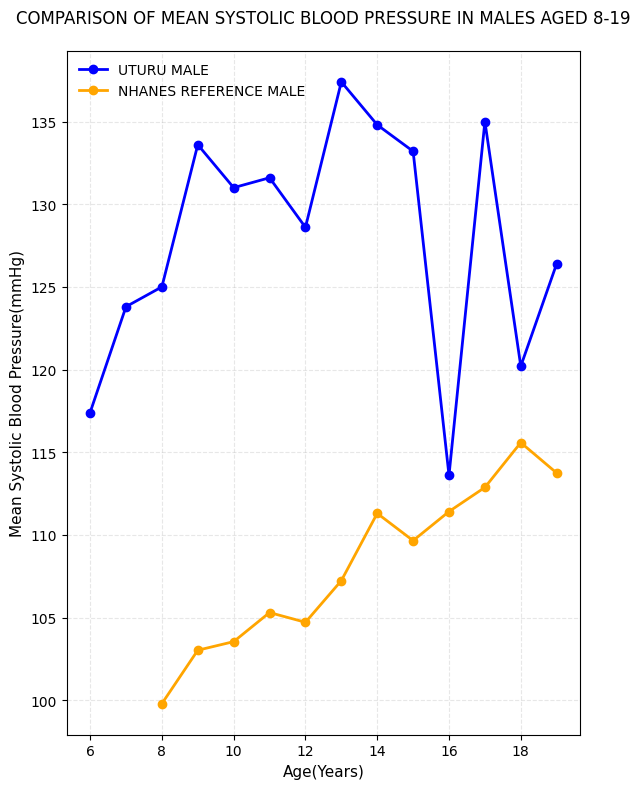

In [ ]:
# Comparing the mean systolic blood pressure of males from both dataset

uturu_ages = uturu_male_bp.index.tolist()
uturu_sbp = uturu_male_bp["mean_SBP"].tolist()

#NHANES reference male sbp - ages 8-19
nhanes_ages = nhanes_male_bp.index.tolist()
nhanes_sbp = nhanes_male_bp["mean_SBP"].tolist()

fig , ax = plt.subplots(figsize = (6,8))

#plot the two line
ax.plot(uturu_ages, uturu_sbp, marker= "o", label = "UTURU MALE", linewidth = 2,color= 'blue')
ax.plot(nhanes_ages , nhanes_sbp ,marker = "o",label = "NHANES REFERENCE MALE", linewidth = 2,color = "orange")

#match the layout
ax.set_xlabel("Age(Years)", fontsize = 11)
ax.set_ylabel("Mean Systolic Blood Pressure(mmHg)",fontsize = 11)
ax.tick_params(axis='x', top=False, labeltop=False, bottom=True, labelbottom=True)

ax.legend(loc="upper left", frameon = False)


plt.title("COMPARISON OF MEAN SYSTOLIC BLOOD PRESSURE IN MALES AGED 8-19", fontsize=12,pad=20)
plt.grid(True,linestyle="--",alpha = 0.3)
plt.tight_layout()
plt.show()

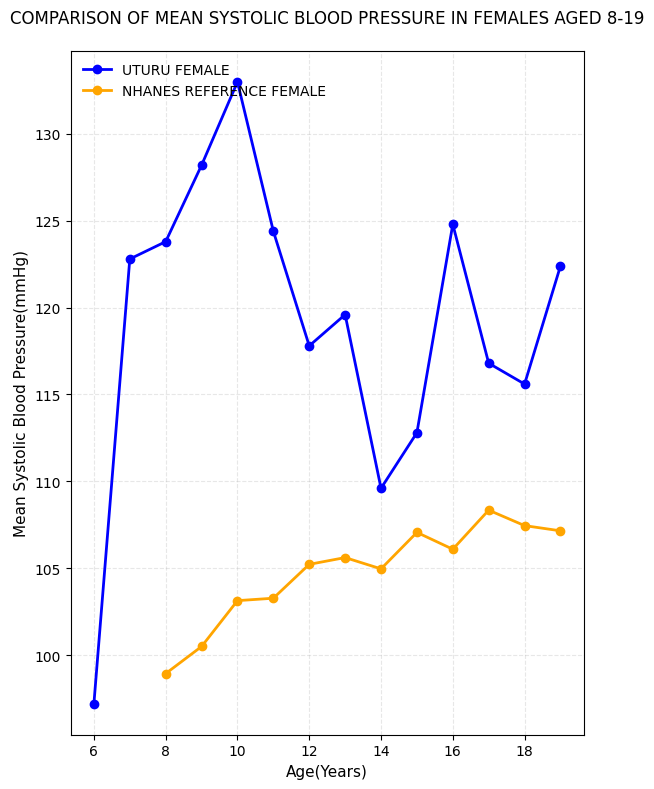

In [ ]:
# Comparing the mean systolic blood pressure of female from both dataset

uturu_ages = uturu_female_bp.index.tolist()
uturu_sbp = uturu_female_bp["mean_SBP"].tolist()

#NHANES reference male sbp - ages 8-19
nhanes_ages = nhanes_female_bp.index.tolist()
nhanes_sbp = nhanes_female_bp["mean_SBP"].tolist()

fig , ax = plt.subplots(figsize = (6,8))

#plot the two line
ax.plot(uturu_ages, uturu_sbp, marker= "o", label = "UTURU FEMALE", linewidth = 2,color= 'blue')
ax.plot(nhanes_ages , nhanes_sbp ,marker = "o",label = "NHANES REFERENCE FEMALE", linewidth = 2,color = "orange")

#match the layout
ax.set_xlabel("Age(Years)", fontsize = 11)
ax.set_ylabel("Mean Systolic Blood Pressure(mmHg)",fontsize = 11)
ax.tick_params(axis='x', top=False, labeltop=False, bottom=True, labelbottom=True)

ax.legend(loc="upper left", frameon = False)


plt.title("COMPARISON OF MEAN SYSTOLIC BLOOD PRESSURE IN FEMALES AGED 8-19", fontsize=12,pad=20)
plt.grid(True,linestyle="--",alpha = 0.3)
plt.tight_layout()
plt.show()

#FIQURE 2 : GRAPHICAL REPRESENTATION SHOWING THE COMPARISON OF MEAN DIASTOLIC BLOOD PRESSURE(DBP) IN BOTH MALES AND FEMALES AGED 8-19 YEARS : UTURU COHORT COMPARED TO NHANES REFERENCE

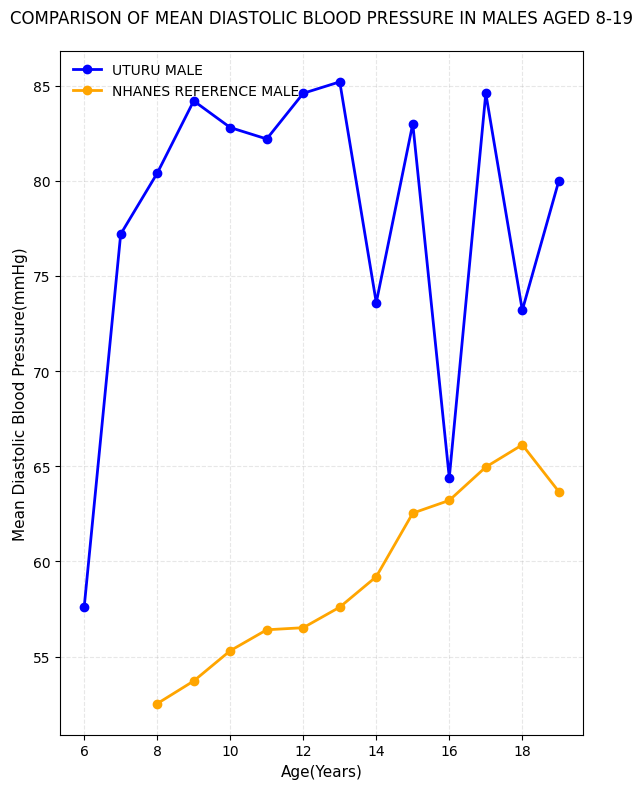

In [ ]:
# Comparing the mean diastolic blood pressure of males from both dataset

uturu_ages = uturu_male_bp.index.tolist()
uturu_dbp = uturu_male_bp["mean_DBP"].tolist()

#NHANES reference male sbp - ages 8-19
nhanes_ages = nhanes_male_bp.index.tolist()
nhanes_dbp = nhanes_male_bp["mean_DBP"].tolist()

fig , ax = plt.subplots(figsize = (6,8))

#plot the two line
ax.plot(uturu_ages, uturu_dbp, marker= "o", label = "UTURU MALE", linewidth = 2,color= 'blue')
ax.plot(nhanes_ages , nhanes_dbp ,marker = "o",label = "NHANES REFERENCE MALE", linewidth = 2,color = "orange")

#match the layout
ax.set_xlabel("Age(Years)", fontsize = 11)
ax.set_ylabel("Mean Diastolic Blood Pressure(mmHg)",fontsize = 11)
ax.tick_params(axis='x', top=False, labeltop=False, bottom=True, labelbottom=True)

ax.legend(loc="upper left", frameon = False)


plt.title("COMPARISON OF MEAN DIASTOLIC BLOOD PRESSURE IN MALES AGED 8-19", fontsize=12,pad=20)
plt.grid(True,linestyle="--",alpha = 0.3)
plt.tight_layout()
plt.show()

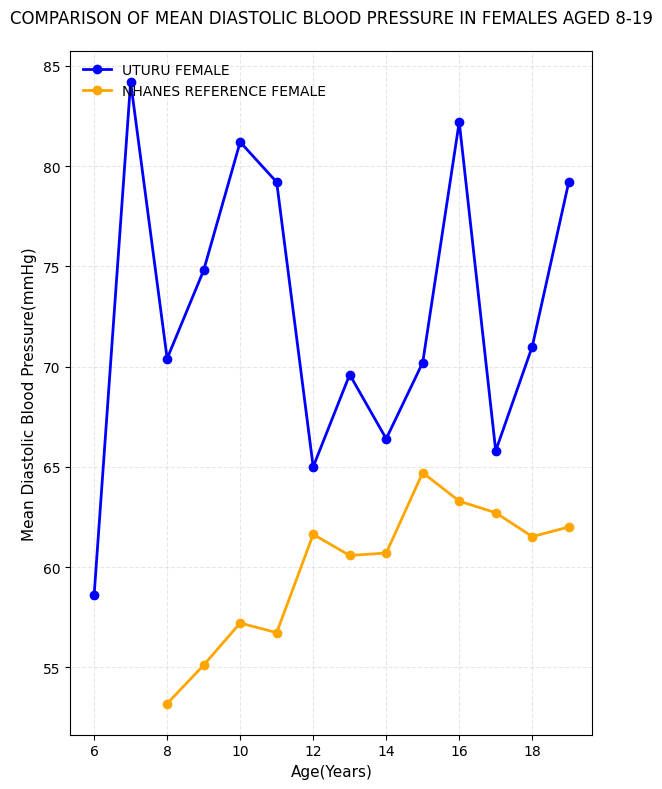

In [ ]:
# Comparing the mean diastolic blood pressure of females from both dataset

uturu_ages = uturu_female_bp.index.tolist()
uturu_dbp = uturu_female_bp["mean_DBP"].tolist()

#NHANES reference male sbp - ages 8-19
nhanes_ages = nhanes_female_bp.index.tolist()
nhanes_dbp = nhanes_female_bp["mean_DBP"].tolist()

fig , ax = plt.subplots(figsize = (6,8))

#plot the two line
ax.plot(uturu_ages, uturu_dbp, marker= "o", label = "UTURU FEMALE", linewidth = 2,color= 'blue')
ax.plot(nhanes_ages , nhanes_dbp ,marker = "o",label = "NHANES REFERENCE FEMALE", linewidth = 2,color = "orange")

#match the layout
ax.set_xlabel("Age(Years)", fontsize = 11)
ax.set_ylabel("Mean Diastolic Blood Pressure(mmHg)",fontsize = 11)
ax.tick_params(axis='x', top=False, labeltop=False, bottom=True, labelbottom=True)

ax.legend(loc="upper left", frameon = False)


plt.title("COMPARISON OF MEAN DIASTOLIC BLOOD PRESSURE IN FEMALES AGED 8-19", fontsize=12,pad=20)
plt.grid(True,linestyle="--",alpha = 0.3)
plt.tight_layout()
plt.show()

#FIQURE 3 :AGE AND SEX SPECIFIC MEAN SYSTOLIC AND DIASTOLIC BLOOD PRESSURE IN  UTURU  CHILDREN  COMPARED TO NHANES REFERENCE

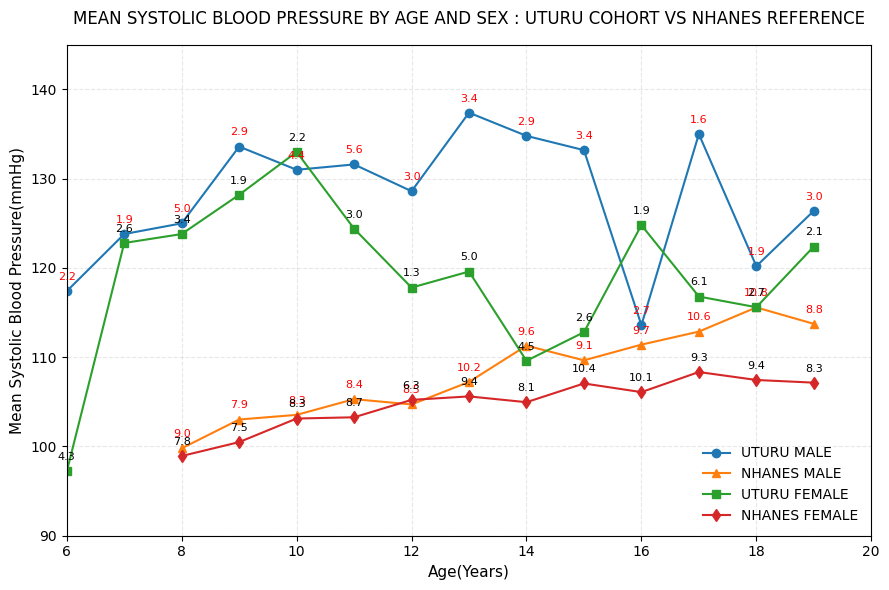

In [ ]:
# AGE AND SEX MEAN SYSTOLIC BLOOD PRESSURE IN UTURU COMPARED TO NHANES DATASET

uturu_male_ages =uturu_male_bp.index.tolist()
nhanes_male_ages = nhanes_male_bp.index.tolist()

uturu_male_sbp = uturu_male_bp["mean_SBP"].tolist()
nhanes_male_sbp = nhanes_male_bp["mean_SBP"].tolist()


uturu_male_std = uturu_male_bp["std_SBP"].tolist()
nhanes_male_std = nhanes_male_bp["std_SBP"]. tolist()

uturu_female_ages = uturu_female_bp.index.tolist()
nhanes_female_ages = nhanes_female_bp.index.tolist()
uturu_female_sbp = uturu_female_bp["mean_SBP"].tolist()
nhanes_female_sbp = nhanes_female_bp["mean_SBP"]. tolist()
uturu_female_std = uturu_female_bp["std_SBP"]. tolist()
nhanes_female_std = nhanes_female_bp["std_SBP"].tolist()



fig, ax = plt.subplots(figsize = (9,6))

#plot 4 lines with error bars
ax.plot(uturu_male_ages,uturu_male_sbp,marker="o", linestyle='-', label = "UTURU MALE")
ax.plot(nhanes_male_ages,nhanes_male_sbp,marker="^", linestyle='-', label = "NHANES MALE")

ax.plot(uturu_female_ages, uturu_female_sbp,marker="s", linestyle='-', label= "UTURU FEMALE")
ax.plot(nhanes_female_ages,nhanes_female_sbp,marker="d", linestyle='-', label = "NHANES FEMALE")


#Annotate SD values for each point
def annotate_sd(ax,x ,y, sd , color):
  for i in range(len(x)):
    ax.annotate(f"{sd[i]:.1f}",
                xy=(x[i], y[i]),
                xytext=(0, 8 ),
                textcoords="offset points",
                ha="center", fontsize=8, color=color)

annotate_sd(ax, uturu_male_ages, uturu_male_sbp, uturu_male_std, "red")
annotate_sd(ax, nhanes_male_ages, nhanes_male_sbp, nhanes_male_std, "red")
annotate_sd(ax, uturu_female_ages, uturu_female_sbp, uturu_female_std, "black")
annotate_sd(ax, nhanes_female_ages, nhanes_female_sbp, nhanes_female_std, "black")

#Formatting
ax.set_ylabel("Mean Systolic Blood Pressure(mmHg)", fontsize= 11)
ax.set_xlabel("Age(Years)", fontsize= 11)
ax.set_xlim(6, 20)
ax.set_ylim(90, 145)
ax.legend( frameon= False, fontsize=10)
ax.grid(True, linestyle="--", alpha= 0.3)

plt.title("MEAN SYSTOLIC BLOOD PRESSURE BY AGE AND SEX : UTURU COHORT VS NHANES REFERENCE", fontsize=12,  pad= 15)
plt.tight_layout()
plt.show()

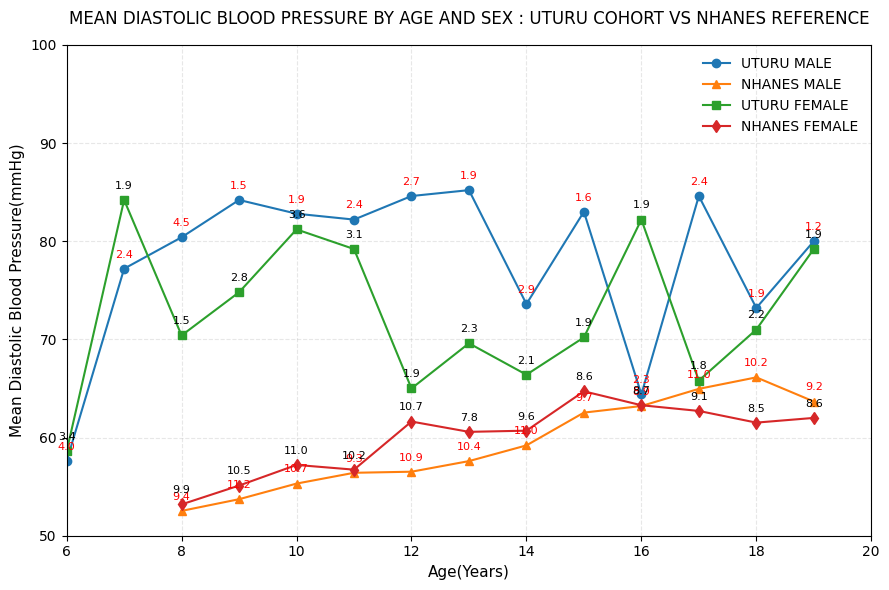

In [ ]:

# AGE AND SEX MEAN DIASTOLIC  BLOOD PRESSURE IN UTURU COMPARED TO NHANES DATASET

uturu_male_ages =uturu_male_bp.index.tolist()
nhanes_male_ages = nhanes_male_bp.index.tolist()

uturu_male_dbp = uturu_male_bp["mean_DBP"].tolist()
nhanes_male_dbp = nhanes_male_bp["mean_DBP"].tolist()


uturu_male_std = uturu_male_bp["std_DBP"].tolist()
nhanes_male_std = nhanes_male_bp["std_DBP"]. tolist()

uturu_female_ages = uturu_female_bp.index.tolist()
nhanes_female_ages = nhanes_female_bp.index.tolist()
uturu_female_dbp = uturu_female_bp["mean_DBP"].tolist()
nhanes_female_dbp = nhanes_female_bp["mean_DBP"]. tolist()
uturu_female_std = uturu_female_bp["std_DBP"]. tolist()
nhanes_female_std = nhanes_female_bp["std_DBP"].tolist()

fig, ax = plt.subplots(figsize = (9,6))

#plot 4 lines with error bars
ax.plot(uturu_male_ages,uturu_male_dbp,marker="o", linestyle='-', label = "UTURU MALE")
ax.plot(nhanes_male_ages,nhanes_male_dbp,marker="^", linestyle='-', label = "NHANES MALE")

ax.plot(uturu_female_ages, uturu_female_dbp,marker="s", linestyle='-', label= "UTURU FEMALE")
ax.plot(nhanes_female_ages,nhanes_female_dbp,marker="d", linestyle='-', label = "NHANES FEMALE")


#Annotate SD values for each point
def annotate_sd(ax,x ,y, sd , color):
  for i in range(len(x)):
    ax.annotate(f"{sd[i]:.1f}",
                xy=(x[i], y[i]),
                xytext=(0, 8 ),
                textcoords="offset points",
                ha="center", fontsize=8, color=color)

annotate_sd(ax, uturu_male_ages, uturu_male_dbp, uturu_male_std, "red")
annotate_sd(ax, nhanes_male_ages, nhanes_male_dbp, nhanes_male_std, "red")
annotate_sd(ax, uturu_female_ages, uturu_female_dbp, uturu_female_std, "black")
annotate_sd(ax, nhanes_female_ages, nhanes_female_dbp, nhanes_female_std, "black")

#Formatting
ax.set_ylabel("Mean Diastolic Blood Pressure(mmHg)", fontsize= 11)
ax.set_xlabel("Age(Years)", fontsize= 11)
ax.set_xlim(6, 20)
ax.set_ylim(50, 100)
ax.legend( frameon= False, fontsize=10)
ax.grid(True, linestyle="--", alpha= 0.3)

plt.title("MEAN DIASTOLIC BLOOD PRESSURE BY AGE AND SEX : UTURU COHORT VS NHANES REFERENCE", fontsize=12,  pad= 15)
plt.tight_layout()
plt.show()